In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from train_model import SegNet, ARMultiAnnDataset, collate_var, FNAME_RE
from sklearn.metrics import jaccard_score
import numpy as np
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az
import os
import xarray as xr
import cartopy.crs as ccrs
import pickle
import math



In [2]:
torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.cuda.get_device_name()

'Tesla V100-PCIE-32GB'

Prediction Masks

In [3]:
import torch
from torch.utils.data import DataLoader

def predict_masks_gpu(
    ckpt_path: str,
    label_dir:     str,
    data_dir:    str,
    var_names:  list[str],
    batch_size: int    = 4,
    use_masks:  bool   = True,
    device:     str    = "cuda"
) -> tuple[torch.Tensor, torch.Tensor]:

    # 1) load checkpoint (weights_only=True silences the pickle warning)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=True)

    # extract the state_dict whichever form it’s in
    if isinstance(ckpt, dict) and "model" in ckpt:
        sd = ckpt["model"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        sd = ckpt["state_dict"]
    else:
        sd = ckpt  # assume ckpt *is* the state dict

    # 2) build & load your SegNet
    net = SegNet().to(device).eval()
    net.load_state_dict(sd)

    # 3) dataset + loader
    ds = ARMultiAnnDataset(
        root        = data_dir,
        var_names   = var_names,
        gt_npy_root = label_dir
    )
    dl = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        collate_fn=collate_var, pin_memory=(device=="cuda")
    )

    preds, gts, trueX, y_means = [], [], [], []
    autocast    = torch.amp.autocast

    # 4) inference
    with torch.no_grad(), autocast(device_type=device, dtype=torch.float16):
        for x_vars, y_lists, y_cons, y_mean in dl:
            x_vars = x_vars.to(device)
            
            if use_masks:
                y_lists = [
                    [m.to(device, dtype=x_vars.dtype) for m in lst]
                    for lst in y_lists
                ]
                logits = net(x_vars)
            else:
                logits = net(x_vars)

            probs = logits #torch.sigmoid(logits)
            preds.append(probs.cpu())
            gts  .append(y_cons)   # already on CPU
            trueX.append(x_vars.cpu())
            y_means.append(y_mean.cpu())
            

    PRED = torch.cat(preds, dim=0)  # [N,1,H,W], fp16
    GT   = torch.cat(gts,   dim=0)  # [N,1,H,W], fp32
    Xvar   = torch.cat(trueX,   dim=0) 
    Y_means = torch.cat(y_means, dim = 0)

    return PRED, GT, Xvar, Y_means



Save and find which areas have most of the ARS

In [6]:
# ─── dataset & loader (batch_size = 1 keeps y_lists as Python lists) ───
ds = ARMultiAnnDataset(
        root        = "/home/sbk29/data/AR/train",
        var_names   = ["TMQ"],
        gt_npy_root = None
)
dl = DataLoader(
        ds, batch_size=1, shuffle=False,
        collate_fn=collate_var, pin_memory=(device == "cuda")
)

# union_masks = []            # will hold one tensor [1,H,W] per sample

# for _, y_lists, _, _ in dl:     # y_lists is a tuple length = batch (here 1)
#     masks = y_lists[0]       # List[Tensor]  (K annotators)  each [1,H,W]

#     # stack → [K,1,H,W] → logical OR (any) over K → [1,H,W]
#     union = torch.stack(masks, dim=0).any(dim=0).float()   # values 0/1
#     union_masks.append(union)

# # (optional) stack all unions into a single tensor [N,1,H,W]
# U = torch.stack(union_masks)      # U[i] is the union mask for sample i

# print(f"Collected {len(union_masks)} union masks; tensor shape {U.shape}")


In [7]:
# ---------- 4. COLLECT ALL MASKS & COMPUTE FREQUENCY -------------------------
all_masks = []   # will hold [1,H,W] tensors (bool/float)

for _, y_lists, _, _ in dl:
    # y_lists is a tuple length=1 → take element 0
    for m in y_lists[0]:          # iterate annotator masks for this date
        all_masks.append(m.bool())  # ensure bool

print(f"Total annotator masks collected: {len(all_masks)}")

# stack → [M,1,H,W]   then mean over M
big_tensor   = torch.stack(all_masks, dim=0).float()        # [M,1,H,W]
prob_map     = big_tensor.mean(0)    

Total annotator masks collected: 398


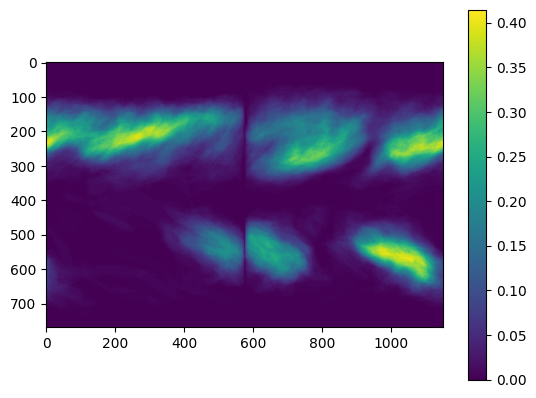

In [8]:
plt.imshow(prob_map[0,:,:])
plt.colorbar()

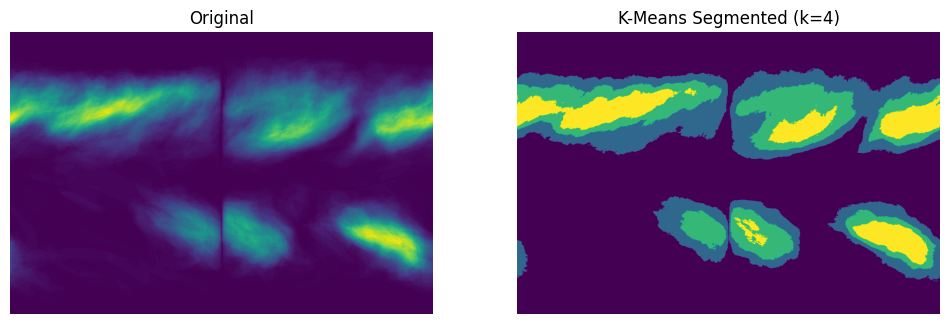

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Suppose img is your H x W grayscale image with values in [0, 1]
# For demonstration, let's create a dummy image:
# img = np.random.rand(H, W)
# Or load with: img = plt.imread('image.png') / 255.0 if it's grayscale
H,W = 768, 1152
# Step 1: Flatten the image
pixels = prob_map[0,:,:].reshape(-1, 1)  # shape (H*W, 1)

# Step 2: Apply KMeans clustering
k = 4 # for example
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixels)

# # Step 3: Get the labels and reshape
# labels = kmeans.labels_.reshape(prob_map[0,:,:].shape)  # shape (H, W)

# # Optional: Replace each pixel with its cluster center for a quantized image
# clustered_img = kmeans.cluster_centers_[labels]


# Step 3: Sort the cluster centers and remap labels
# Get sorted indices of cluster centers
sorted_indices = np.argsort(kmeans.cluster_centers_.ravel())  # shape (k,)

# Map original labels to sorted labels
label_map = np.zeros_like(sorted_indices)
label_map[sorted_indices] = np.arange(k)

# Remap the labels
sorted_labels = label_map[kmeans.labels_]
sorted_labels_image = sorted_labels.reshape(H, W)



# Step 4: Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(prob_map[0,:,:], cmap='viridis')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"K-Means Segmented (k={k})")
plt.imshow(sorted_labels_image, cmap='viridis')
plt.axis('off')
plt.show()


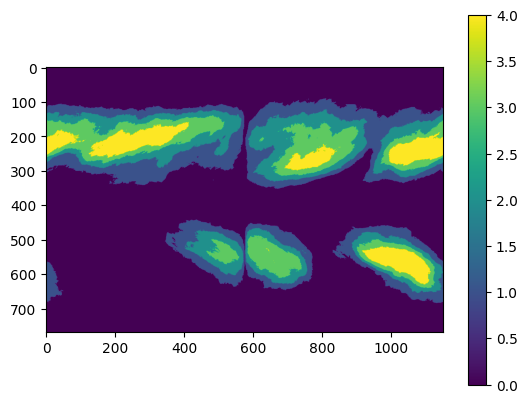

In [82]:
plt.imshow(sorted_labels_image)
plt.colorbar()


In [ ]:
# # Make sure it’s on CPU for fancy indexing
# p = prob_map.cpu()

# # ---------- build class map ----------------------------------------------
# cls_map = torch.empty_like(p, dtype=torch.uint8)   # same shape [1,H,W]

# cls_map[(p > 0.3)]                     = 3                          
# cls_map[(p > 0.15) & (p <= 0.3)]       = 2         # mid
# cls_map[(p > 0.05) & (p <= 0.15)]      = 1
# cls_map[p <= 0.05]                     = 0         # low

In [ ]:
# cls_map = sorted_labels_image

In [10]:
plt.imshow(custom_cluster_map)
plt.colorbar()

NameError: name 'custom_cluster_map' is not defined

In [9]:
import torch.nn.functional as F

In [11]:
pred, gt, xvar, y_means = predict_masks_gpu(
    ckpt_path = "/home/sbk29/data/github_AR/AR_detection/runs/arseg/unet_BCE_PL_new.pt",
    data_dir  = "/home/sbk29/data/AR/validation",
    label_dir = None,
    var_names = ["TMQ"],
    batch_size= 4,
    use_masks = "True",          # no human masks available
    device    = "cuda"          # keep everything on GPU
)

In [12]:
custom_cluster_map = sorted_labels_image # cls_map.squeeze().cpu().numpy() ##

In [ ]:
# custom_cluster_map = np.load("/home/sbk29/data/github_AR/AR_detection/u_net/tmq_based_cluster_map.npy")

In [13]:
np.unique(custom_cluster_map)

array([0, 1, 2, 3])

In [14]:
p_uncal = 1/(1 + torch.exp(-pred))

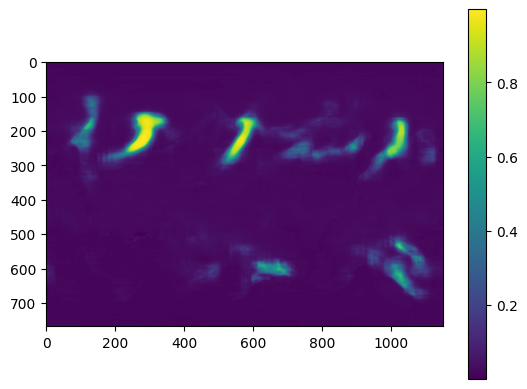

In [16]:
plt.imshow(p_uncal[10,0,:,:].cpu())
plt.colorbar()

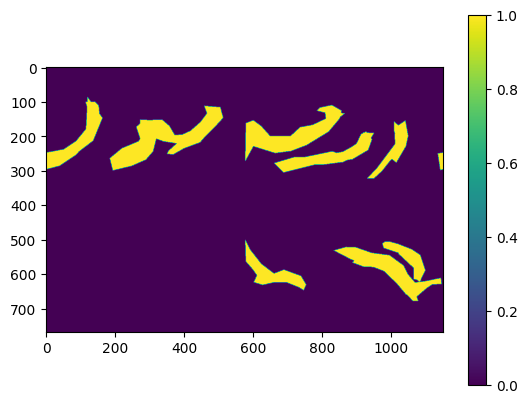

In [17]:
plt.imshow(y_means[10,0,:,:].cpu()>0.3)
plt.colorbar()

Creating the nc curves

In [18]:
# The updated one : 

print("Starting REVISED calibration phase: Pooling all raw scores...")

# Assume your custom cluster map is loaded (replace with your actual loading code)
H, W = pred.shape[-2], pred.shape[-1]
# custom_cluster_map = cls_map[0,:,:].numpy()

# --- Step 0: Prepare Data ---
pred_sigmoid = 1/(1 + torch.exp(-pred))
y_prob = pred_sigmoid.squeeze().cpu().numpy()
y_true = gt.squeeze().cpu().numpy()>0
y_true = y_true.astype(int)

# --- Step 1: Initialize Score Lists for Each Cluster ---
num_clusters = 4
cluster_scores = {i: [] for i in range(num_clusters)}
print(f"Found {num_clusters} clusters. Pooling scores...")

# --- Step 2: Pool the Non-Conformity Scores (This logic is the same) ---
for i in range(y_prob.shape[0]):  # Loop through each of the 16 validation images
    prob_map = y_prob[i]
    true_mask = y_true[i]
    nc_scores = 1.0 - prob_map
    # nc_scores = np.where(true_mask == 1, nc_scores, np.nan)
    foreground_mask = (true_mask == 1)

    for k in range(num_clusters):
        cluster_k_mask = (custom_cluster_map == k)
        combined_mask = foreground_mask & cluster_k_mask #  
        scores_to_add = nc_scores[combined_mask]
        cluster_scores[k].extend(scores_to_add.tolist())

# --- Step 3 (REVISED): Save the Raw Pooled Scores ---
# Instead of calculating quantiles now, we save the raw data.
output_filename = "bag_calibration_scores_raw.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(cluster_scores, f)

print("-" * 30)
print("✅ Calibration phase complete!")
print(f"Raw calibration scores for each cluster saved to '{output_filename}'.")
print("Note: This file may be significantly larger than before.")
print("-" * 30)

Starting REVISED calibration phase: Pooling all raw scores...
Found 4 clusters. Pooling scores...
------------------------------
✅ Calibration phase complete!
Raw calibration scores for each cluster saved to 'bag_calibration_scores_raw.pkl'.
Note: This file may be significantly larger than before.
------------------------------


In [19]:
len(cluster_scores)

4

(array([92631., 26524., 21137., 18822., 18313., 20530., 21717., 26292.,
        33976., 66243.]),
 array([0.        , 0.09848633, 0.19697266, 0.29545898, 0.39394531,
        0.49243164, 0.59091797, 0.6894043 , 0.78789062, 0.88637695,
        0.98486328]),
 <BarContainer object of 10 artists>)

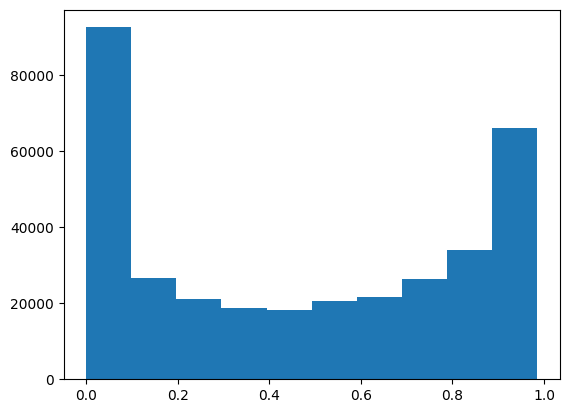

In [20]:
plt.hist(cluster_scores[3])

In [21]:
# --- The Formal Quantile Function We Discussed ---
def calculate_q_hat_formal(scores, alpha):
    """Calculates the conformal threshold q_hat using the formal quantile definition."""
    # if not scores: # Handle empty list for a cluster
    #     return np.inf
    n = len(scores)
    k = math.ceil(((n + 1) * (1 - alpha)))
    # if k > n:
    #     return np.inf
    # Return the k-th smallest score (k-1 for 0-based index)
    return np.sort(scores)[k]
    # return np.quantile(scores,k)

# n = len(cal_scores)
#     q = np.ceil((n + 1) * (1 - significance)) / n
#     threshold = np.quantile(cal_scores, q)






# --- Part 1: Setup and Loading Assets ---
print("Starting REVISED testing phase with formal quantile calculation...")

# Load the raw calibration scores we just saved
calibration_filename = "/home/sbk29/data/github_AR/AR_detection/u_net/bag_calibration_scores_raw.pkl"
with open(calibration_filename, "rb") as f:
    cluster_scores = pickle.load(f)
print(f"Successfully loaded raw scores from '{calibration_filename}'.")

# Get predictions for your 16 TEST images
print("Running model on the test set...")


pred_test, gt_test, _, _ = predict_masks_gpu(
    ckpt_path="/home/sbk29/data/github_AR/AR_detection/runs/arseg/unet_BCE_PL_new.pt",
    data_dir="/home/sbk29/data/AR/test", # <-- IMPORTANT: Point to your test directory
    label_dir=None,
    var_names=["TMQ"],
    batch_size=4,
    use_masks="True",
    device="cuda"
)
pred_test_sigmoid =  1/(1 + torch.exp(-pred_test))



Starting REVISED testing phase with formal quantile calculation...
Successfully loaded raw scores from '/home/sbk29/data/github_AR/AR_detection/u_net/bag_calibration_scores_raw.pkl'.
Running model on the test set...


In [40]:
# --- Part 2: Calculate q_hat For Each Cluster ---
alpha = 0.4
cluster_q_hats = {}
num_clusters = len(cluster_scores)

print(f"Calculating formal q_hat for each cluster with alpha = {alpha}...")
for k in range(num_clusters):
    scores_for_cluster_k = cluster_scores[k]
    q_hat = calculate_q_hat_formal(scores_for_cluster_k, alpha)
    cluster_q_hats[k] = q_hat
    # print(f"  Cluster {k}: q_hat = {q_hat:.4f} (based on {len(scores_for_cluster_k)} scores)")

print("All cluster thresholds calculated.")


# --- Part 3: Loop Through Test Images and Evaluate ---
# This part is largely the same, but uses our new cluster_q_hats dictionary
prediction_sets = []
true_masks = []


y_prob_test_all = pred_test_sigmoid.squeeze().cpu().numpy()
y_true_test_all = gt_test.squeeze().cpu().numpy()>0
y_true_test_all = y_true_test_all.astype(int)

print(f"Generating conformal prediction sets for {y_prob_test_all.shape[0]} test images...")
for i in range(y_prob_test_all.shape[0]):
    test_cluster_map = custom_cluster_map # Load the cluster map for this test image
    q_hat_map = np.zeros_like(test_cluster_map, dtype=float)

    # Build the threshold map using our formally calculated q_hats
    for k in range(num_clusters):
        q_hat_map[test_cluster_map == k] = cluster_q_hats[k]

    # Perform inference
    y_prob = y_prob_test_all[i]
    s_fg = 1.0 - y_prob
    prediction_set_mask = (s_fg <= q_hat_map  )

    # Store results for final evaluation
    prediction_sets.append(prediction_set_mask)
    true_masks.append(y_true_test_all[i])

Calculating formal q_hat for each cluster with alpha = 0.4...
All cluster thresholds calculated.
Generating conformal prediction sets for 16 test images...


In [23]:
cluster_q_hats

{0: 0.970703125, 1: 0.95263671875, 2: 0.919921875, 3: 0.775390625}

In [ ]:
# pred_test, gt_test, _, _ = predict_masks_gpu(
#     ckpt_path="/home/sbk29/data/github_AR/AR_detection/runs/arseg/unet_Jaccard_PL_new.pt",
#     data_dir="/home/sbk29/data/AR/test", # <-- IMPORTANT: Point to your test directory
#     label_dir=None,
#     var_names=["TMQ"],
#     batch_size=4,
#     use_masks="True",
#     device="cuda"
# )
# pred_test_sigmoid =  1/(1 + torch.exp(-pred_test))


Now we will check the non-conformity on the test set

In [28]:
ind = 12

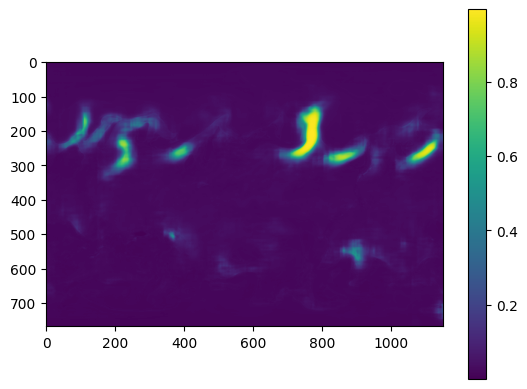

In [41]:
plt.imshow(y_prob_test_all[ind,:,:])
plt.colorbar()


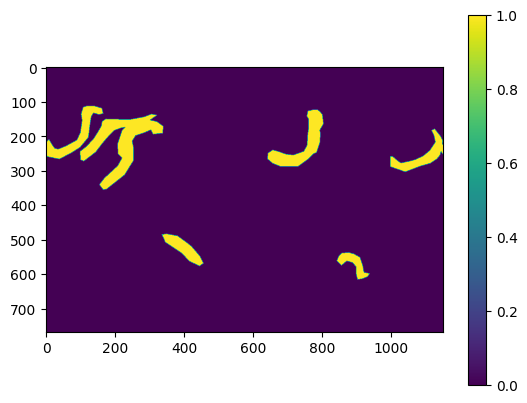

In [42]:
plt.imshow(y_true_test_all[ind,:,:])
plt.colorbar()

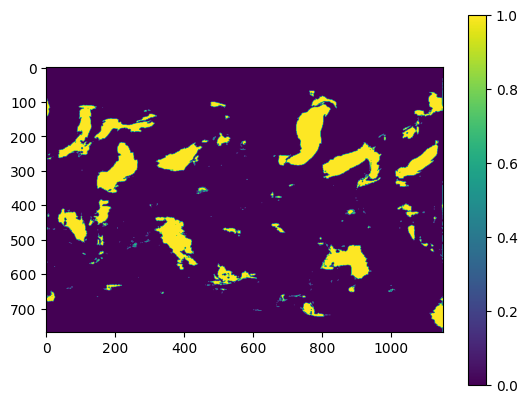

In [43]:
plt.imshow(prediction_sets[ind])
plt.colorbar()

In [29]:
true_flat = y_true_test_all[14, :, :].ravel()    # shape (768*1152,)
pred_flat = prediction_sets[14].ravel()  # shape (768*1152,)

In [30]:
jaccard_score(true_flat,pred_flat)

0.30507309396612414

In [45]:
# Assuming true_mask has shape (61, 1, 768, 1152)
# and predicted_mask has shape (61, 768, 1152) (adjust indexing if needed)
num_samples = y_true_test_all.shape[0]
scores = []

for i in range(num_samples):
    # Flatten the true mask and predicted mask for each sample.
    true_flat = y_true_test_all[i, :, :].ravel()    # shape (768*1152,)
    pred_flat = prediction_sets[i].ravel()  # shape (768*1152,)
    pred_flat = pred_flat.ravel()
    
    # Compute the Jaccard score for the binary classification
    score = dice_coefficient(true_flat, pred_flat)
    scores.append(score)

# Compute the average Jaccard score across all samples
average_dice = np.mean(scores)
print("Average Jaccard Score:", average_jaccard)

Average Jaccard Score: 0.40548441530575796


In [46]:
scores

[0.41135575729101065,
 0.6023783827625397,
 0.45374658989969935,
 0.4597953866717938,
 0.27206341450666405,
 0.37092077370978777,
 0.42785110567893414,
 0.46891187992620104,
 0.5195350823559854,
 0.6145573918966295,
 0.44766312924536306,
 0.413090345916469,
 0.44121856471492443,
 0.42659986822685386,
 0.4318075007087682,
 0.502701917961153]

In [47]:
import numpy as np

# Let's assume these variables are populated from your testing script.
# Each list contains 16 NumPy arrays of shape (768, 1152).
# For this example, we'll create some dummy data.
# In your code, you will use your actual data.
H, W = 768, 1152

true_masks = y_true_test_all


# --- Start of the Calculation ---

if not prediction_sets or len(prediction_sets) == 0:
    print("Error: No data to evaluate.")
else:
    num_test_images = len(true_masks)
    foreground_coverage_percentages = []
    
    print(f"Calculating Foreground Coverage Percentage for {num_test_images} images...")
    
    # Loop through each test image and its corresponding prediction set
    for i in range(num_test_images):
        pred_set = prediction_sets[i]
        true_mask = true_masks[i]
        
        # 1. Identify the pixels that are truly foreground.
        foreground_pixels_mask = (true_mask == 1)
        total_fg_pixels = np.sum(foreground_pixels_mask)
        
        # 2. Handle the edge case where an image has no foreground pixels.
        if total_fg_pixels == 0:
            # We can't divide by zero. Coverage is undefined or trivially 100%.
            # Let's skip this image for the average calculation.
            print(f"  Image {i+1:02d}: Skipped (no foreground pixels in ground truth).")
            continue
            
        # 3. Count how many of the true foreground pixels were actually covered.
        # This selects the boolean values from pred_set only where true_mask is 1.
        covered_fg_pixels_mask = pred_set[foreground_pixels_mask]
        num_covered_fg_pixels = np.sum(covered_fg_pixels_mask)
        
        # 4. Calculate the percentage for this image.
        coverage_percentage = (num_covered_fg_pixels / total_fg_pixels) * 100
        foreground_coverage_percentages.append(coverage_percentage)
        
        print(f"  Image {i+1:02d}: Covered {num_covered_fg_pixels} of {total_fg_pixels} foreground pixels ({coverage_percentage:.2f}%).")

    # --- Calculate and Report the Final Average ---
    if foreground_coverage_percentages:
        average_fg_coverage = np.mean(foreground_coverage_percentages)
        std_dev_fg_coverage = np.std(foreground_coverage_percentages)

        print("\n" + "="*50)
        print("      Average Foreground Coverage Percentage Results")
        print("="*50)
        print(f"Average Foreground Coverage Percentage: {average_fg_coverage:.2f}%")
        print(f"Standard Deviation of Percentages:    {std_dev_fg_coverage:.2f}%")
        print("="*50)
    else:
        print("\nNo images with foreground pixels were found to evaluate.")

Calculating Foreground Coverage Percentage for 16 images...
  Image 01: Covered 33283 of 47717 foreground pixels (69.75%).
  Image 02: Covered 59443 of 76424 foreground pixels (77.78%).
  Image 03: Covered 33847 of 55115 foreground pixels (61.41%).
  Image 04: Covered 36179 of 70719 foreground pixels (51.16%).
  Image 05: Covered 20044 of 31411 foreground pixels (63.81%).
  Image 06: Covered 25284 of 45648 foreground pixels (55.39%).
  Image 07: Covered 38396 of 56437 foreground pixels (68.03%).
  Image 08: Covered 49017 of 135392 foreground pixels (36.20%).
  Image 09: Covered 45012 of 71033 foreground pixels (63.37%).
  Image 10: Covered 70577 of 118729 foreground pixels (59.44%).
  Image 11: Covered 38155 of 59208 foreground pixels (64.44%).
  Image 12: Covered 46944 of 85315 foreground pixels (55.02%).
  Image 13: Covered 29133 of 43974 foreground pixels (66.25%).
  Image 14: Covered 35934 of 77673 foreground pixels (46.26%).
  Image 15: Covered 32158 of 47174 foreground pixels (68

In [114]:
import numpy as np
from skimage.measure import label, regionprops

def filter_blobs_by_shape(mask: np.ndarray, min_area: int, min_eccentricity: float) -> np.ndarray:
    """
    Filters a boolean mask to keep only blobs that meet both size and
    elongation criteria.

    Args:
        mask (np.ndarray): The input boolean segmentation mask.
        min_area (int): The minimum pixel area for a blob to be kept.
        min_eccentricity (float): The minimum eccentricity (0-1) for a blob to be kept.
                                  Values closer to 1 are more elongated.

    Returns:
        np.ndarray: A new boolean mask with non-elongated/small blobs removed.
    """
    # 'label' finds all connected components and gives each a unique integer ID
    labeled_mask = label(mask)
    
    clean_mask = np.zeros_like(mask, dtype=bool)
    
    # 'regionprops' calculates properties for each labeled region (each blob)
    for region in regionprops(labeled_mask):
        # We apply our two conditions to each blob found
        if region.area >= min_area and region.eccentricity >= min_eccentricity:
            # If the blob passes both tests, we add it back to our clean mask.
            # region.coords contains the (row, col) coordinates of every pixel
            # in the blob, so we can efficiently set them to True.
            for coord in region.coords:
                clean_mask[coord[0], coord[1]] = True
                
    return clean_mask

Applying shape-based filtering to existing prediction sets...
  Mask 01: 173202 pixels -> 165552 pixels
  Mask 02: 175038 pixels -> 168738 pixels
  Mask 03: 152511 pixels -> 144483 pixels
  Mask 04: 136377 pixels -> 128332 pixels
  Mask 05: 174811 pixels -> 168452 pixels
  Mask 06: 148750 pixels -> 140599 pixels
  Mask 07: 177797 pixels -> 170696 pixels
  Mask 08: 124551 pixels -> 118016 pixels
  Mask 09: 152775 pixels -> 145490 pixels
  Mask 10: 156718 pixels -> 138540 pixels
  Mask 11: 158408 pixels -> 150742 pixels
  Mask 12: 200615 pixels -> 193196 pixels
  Mask 13: 140968 pixels -> 133827 pixels
  Mask 14: 145580 pixels -> 136825 pixels
  Mask 15: 157709 pixels -> 147615 pixels
  Mask 16: 176730 pixels -> 168538 pixels

✅ Filtering complete.
The 'clean_prediction_sets' list now contains your post-processed masks.


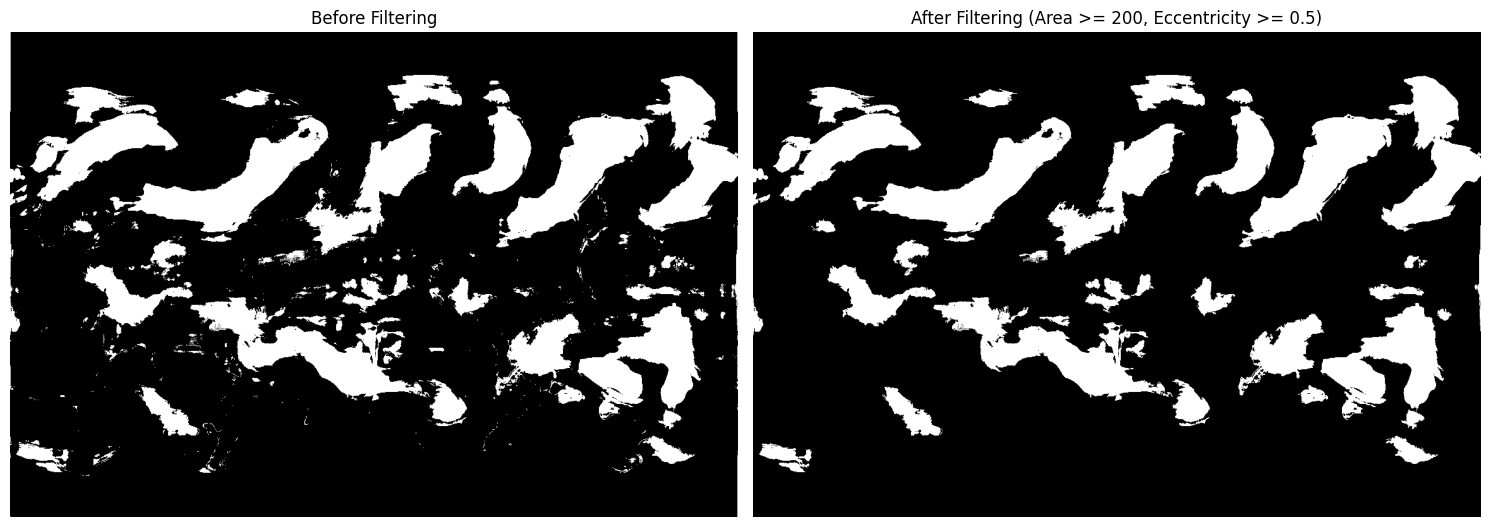

In [120]:
# --- Step 1: Define the Filtering Function ---
def filter_blobs_by_shape(mask: np.ndarray, min_area: int, min_eccentricity: float) -> np.ndarray:
    """
    Filters a boolean mask to keep only blobs that meet both size and
    elongation criteria.
    """
    # 'label' finds all connected components and gives each a unique integer ID
    labeled_mask = label(mask)
    clean_mask = np.zeros_like(mask, dtype=bool)
    
    # 'regionprops' calculates properties for each labeled region (each blob)
    for region in regionprops(labeled_mask):
        # We apply our two conditions to each blob found
        if region.area >= min_area and region.eccentricity >= min_eccentricity:
            # If the blob passes both tests, add it back to our clean mask
            for coord in region.coords:
                clean_mask[coord[0], coord[1]] = True
                
    return clean_mask


# --- Step 2: Define Your Filtering Thresholds ---
# These are the hyperparameters you can now easily experiment with.
min_area_threshold = 200         # e.g., must be at least 100 pixels
min_eccentricity_threshold = 0.5 # e.g., must be highly elongated


# --- Step 3: Apply the Filter to Each Mask in Your Existing List ---
print("Applying shape-based filtering to existing prediction sets...")
clean_prediction_sets = []
for i, raw_mask in enumerate(prediction_sets):
    # Apply our new, advanced filter to the raw mask
    clean_mask = filter_blobs_by_shape(
        raw_mask,
        min_area=min_area_threshold,
        min_eccentricity=min_eccentricity_threshold
    )
    clean_prediction_sets.append(clean_mask)
    
    # Optional: Compare the number of pixels before and after
    print(f"  Mask {i+1:02d}: {np.sum(raw_mask)} pixels -> {np.sum(clean_mask)} pixels")

print("\n✅ Filtering complete.")
print("The 'clean_prediction_sets' list now contains your post-processed masks.")

# --- Step 4: Visualize a Before-and-After Example ---
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(prediction_sets[0], cmap='gray')
axes[0].set_title('Before Filtering')
axes[0].set_axis_off()

axes[1].imshow(clean_prediction_sets[0], cmap='gray')
axes[1].set_title(f'After Filtering (Area >= {min_area_threshold}, Eccentricity >= {min_eccentricity_threshold})')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


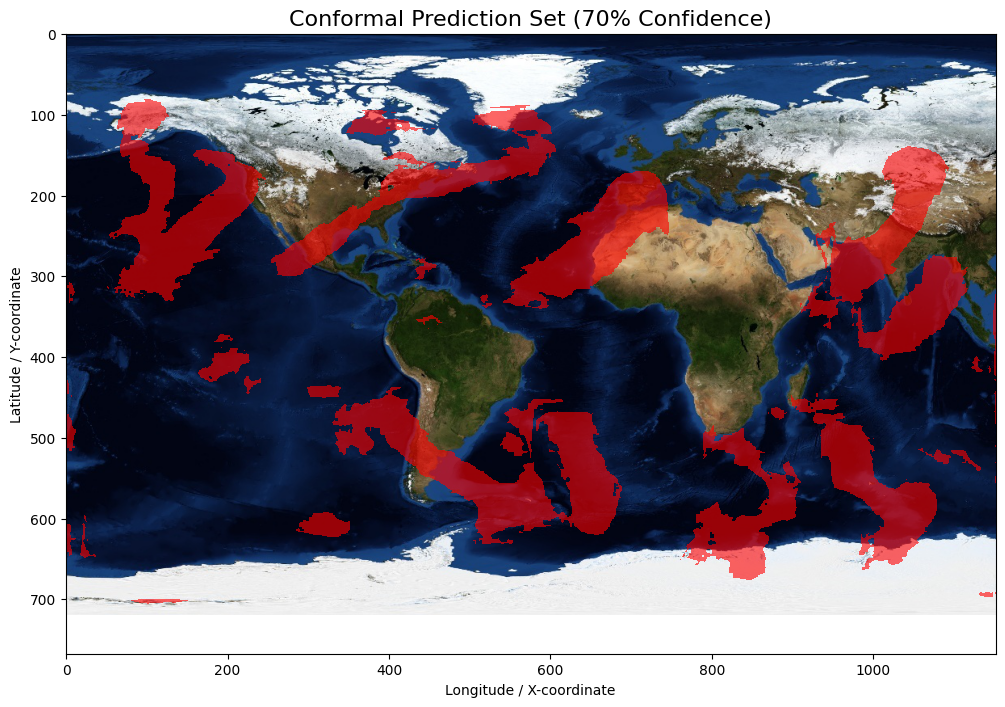

In [122]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg  # Import the image module from matplotlib

# Let's assume you have your data loaded:
# bm: Your world image, loaded as a NumPy array (e.g., shape HxWx3).
# prediction_sets: Your list of 16 boolean masks.

# --- Select the specific data you want to plot ---
# We'll use the 10th prediction set, which is at index 9.
prediction_mask = clean_prediction_sets[9]
bm_path = "/home/sbk29/data/github_AR/AR_detection/climatenet/bluemarble/BM.jpeg"
bm = mpimg.imread(bm_path)
# --- Create the plot ---
# Using subplots gives us more control over the figure
fig, ax = plt.subplots(figsize=(12, 10))

# 1. Plot the basemap image first. This will be the bottom layer.
ax.imshow(bm)

# 2. Create a version of the mask suitable for overlaying.
# To make the 'False' values (background) completely transparent,
# we can use a NumPy masked array.
overlay_data = np.ma.masked_where(prediction_mask == False, prediction_mask)

# 3. Plot the prediction set on top with transparency.
# We use a colormap to give the 'True' values a color.
# 'alpha' controls how see-through the overlay is (0.0 to 1.0).
ax.imshow(overlay_data, cmap='autumn', alpha=0.6)


# --- Add professional touches for your research paper ---
ax.set_title('Conformal Prediction Set (70% Confidence)', fontsize=16)
ax.set_xlabel('Longitude / X-coordinate')
ax.set_ylabel('Latitude / Y-coordinate')
ax.grid(False) # A grid is usually distracting on a map image

# Save the figure in high resolution
# plt.savefig('conformal_overlay.png', dpi=300, bbox_inches='tight')

plt.show()

In [35]:
import numpy as np

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Computes the Dice coefficient between two binary masks.

    Args:
        y_true (np.array): Ground truth mask (binary).
        y_pred (np.array): Predicted mask (binary).
        smooth (float): A small constant to prevent division by zero.

    Returns:
        float: The computed Dice coefficient.
    """
    intersection = np.sum(y_true * y_pred)
    sum_of_masks = np.sum(y_true) + np.sum(y_pred)
    dice = (2. * intersection + smooth) / (sum_of_masks + smooth)
    return dice

In [185]:
prediction_sets = []
true_masks = []

print(f"\nGenerating conformal prediction sets for {y_prob_test_all.shape[0]} test images...")
for i in range(y_prob_test_all.shape[0]):
    # Get the data for the i-th test image
    y_prob = y_prob_test_all[i]
    y_true = y_true_test_all[i]
    # You need to load the corresponding cluster map for this test image
    # For this example, we regenerate a placeholder. You must load your actual map.
    cluster_map = np.random.randint(0, num_clusters, size=y_prob.shape)

    # --- Step 2.1: Build the Threshold Map (q_hat_map) for THIS image ---
    quantile_index = int(0.5 * 100)
    q_hat_map = np.zeros_like(y_prob)

    for k in range(num_clusters):
        # Look up the pre-calculated threshold for this cluster
        q_hat_for_cluster_k = cluster_nc_curves[k][quantile_index]
        # "Paint" this threshold onto the map where the pixels belong to cluster k
        q_hat_map[cluster_map == k] = q_hat_for_cluster_k

    # --- Step 2.2: Calculate Scores and Apply the Conformal Test ---
    s_fg = 1.0 - y_prob
    prediction_set_mask = (s_fg <= q_hat_map)

    # --- Step 2.3: Store results for final evaluation ---
    prediction_sets.append(prediction_set_mask)
    true_masks.append(y_true)

print("Finished generating all prediction sets.")


Generating conformal prediction sets for 16 test images...
Finished generating all prediction sets.


In [186]:
prediction_sets_np = np.array(prediction_sets)

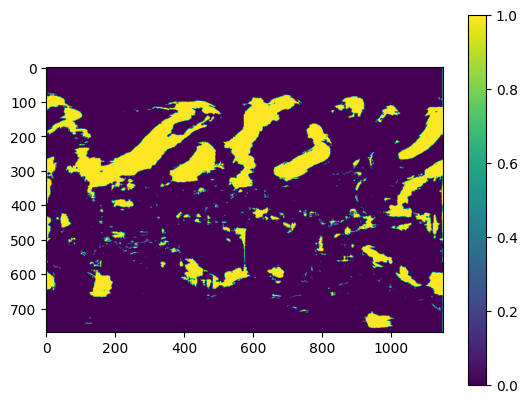

In [125]:
plt.imshow(prediction_sets[3])
plt.colorbar()

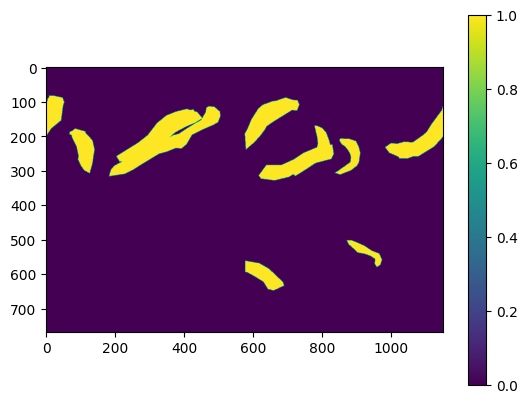

In [206]:
plt.imshow(y_true_test_all[3,:,:])
plt.colorbar()

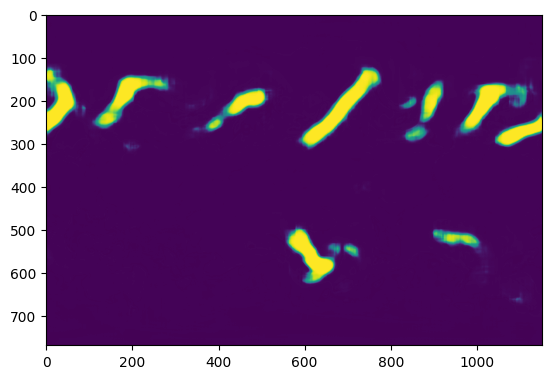

In [175]:
plt.imshow(y_prob_test_all[1,:,:])

In [15]:
# Let's say you have k=5 custom clusters
num_clusters = 5
cluster_scores = {i: [] for i in range(num_clusters)}

In [ ]:
# 'validation_images' is your set of 16 images and their labels
for image_data in validation_images:
    # Load data for one validation image
    y_prob = pred[]        # Shape: [H, W]
    y_true = image_data["ground_truth"]          # Shape: [H, W]
    cluster_map = image_data["custom_cluster_map"] # Shape: [H, W]

    # Calculate non-conformity scores for the foreground class
    nc_scores = 1.0 - y_prob

    # Find the pixels that are truly foreground
    foreground_mask = (y_true == 1)

    # For each cluster, get the scores of the foreground pixels
    # that fall within that cluster
    for i in range(num_clusters):
        cluster_i_mask = (cluster_map == i)
        combined_mask = foreground_mask & cluster_i_mask
        scores_to_add = nc_scores[combined_mask]
        cluster_scores[i].extend(scores_to_add)

{0: [], 1: [], 2: [], 3: [], 4: []}

/tmp/ipykernel_1010871/2221399597.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


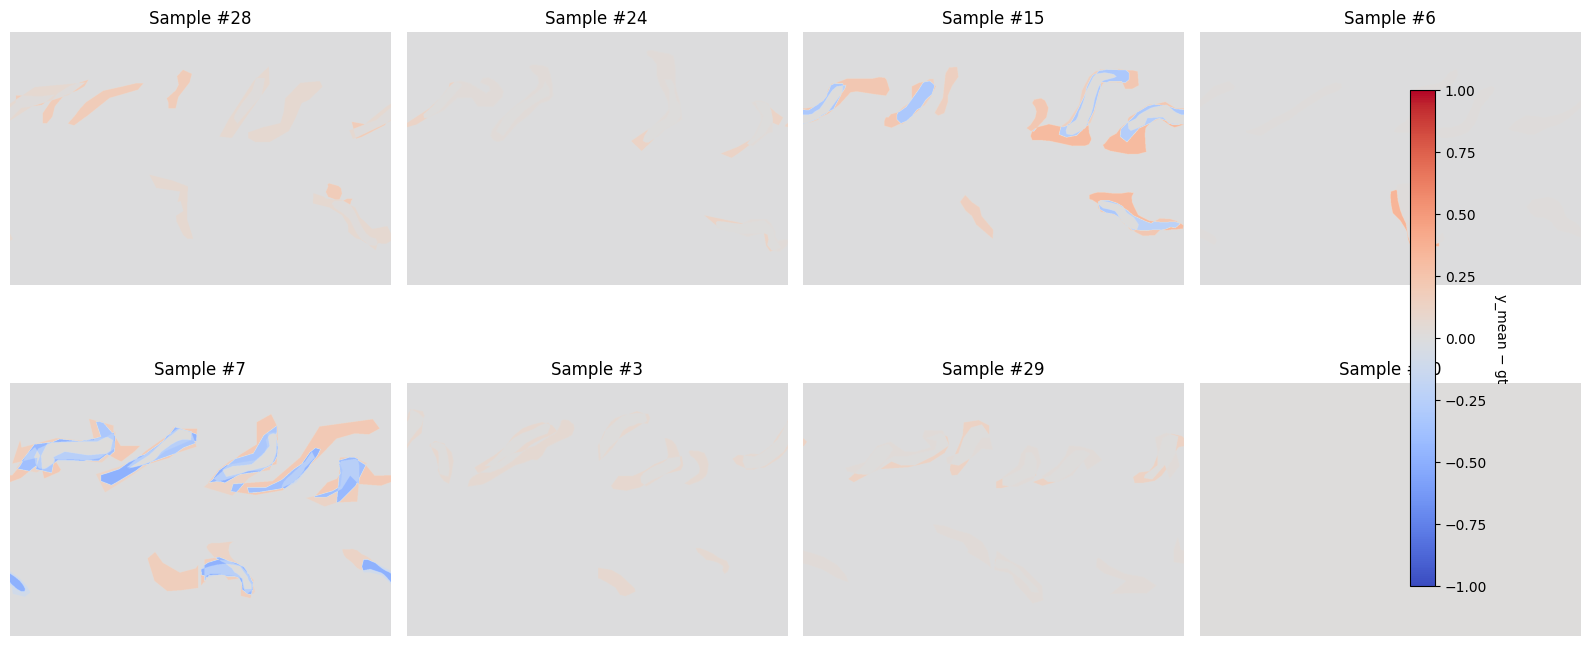

In [ ]:
# import matplotlib.pyplot as plt

# plot_idxs = [28, 24, 15, 6, 7, 3, 29, 30]
# n = len(plot_idxs)

# # Choose a grid layout (e.g., 2 rows × ceil(n/2) columns)
# ncols = 4
# nrows = (n + ncols - 1) // ncols

# fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
# axes = axes.flatten()  # flatten so we can index 0..n-1

# for ax, p in zip(axes, plot_idxs):
#     # Compute difference: y_mean minus ground truth
#     diff = (y_means[p, 0, :, :].cpu() - gt[p, 0, :, :].cpu()).numpy()

#     im = ax.imshow(diff, cmap="coolwarm", vmin=-1, vmax=1)
#     ax.set_title(f"Sample #{p}")
#     ax.axis("off")

# # Turn off any unused subplots
# for ax in axes[n:]:
#     ax.axis("off")

# # Add a single colorbar for all subplots
# cbar = fig.colorbar(im, ax=axes[:n], fraction=0.02, pad=0.01)
# cbar.set_label("y_mean − gt", rotation=270, labelpad=15)

# plt.tight_layout()
# plt.show()



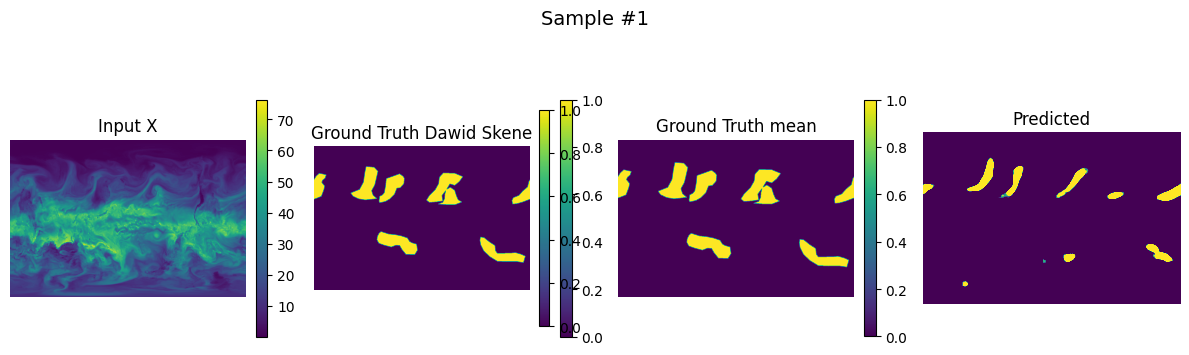

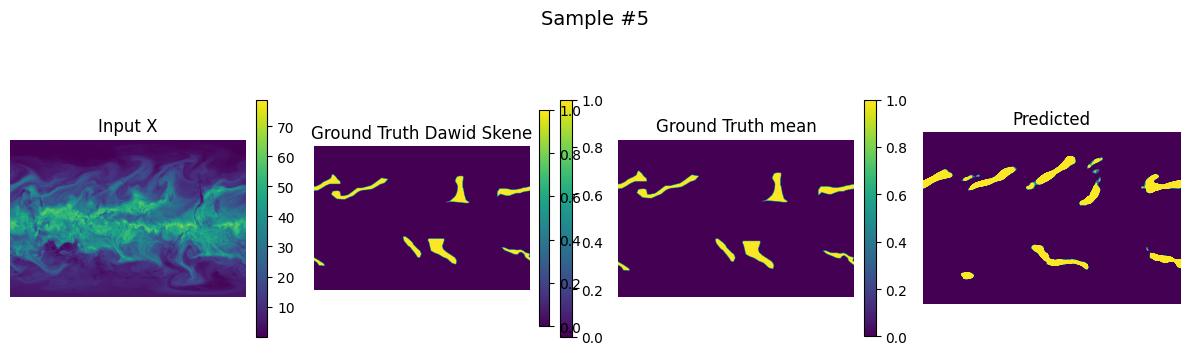

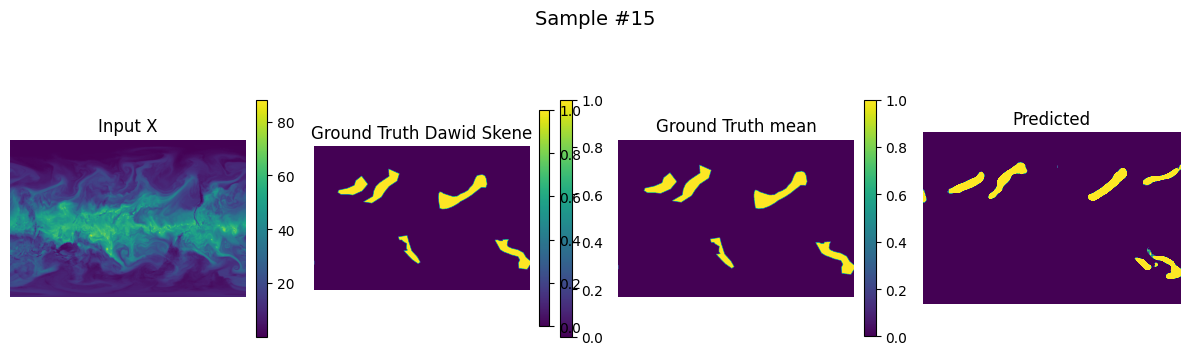

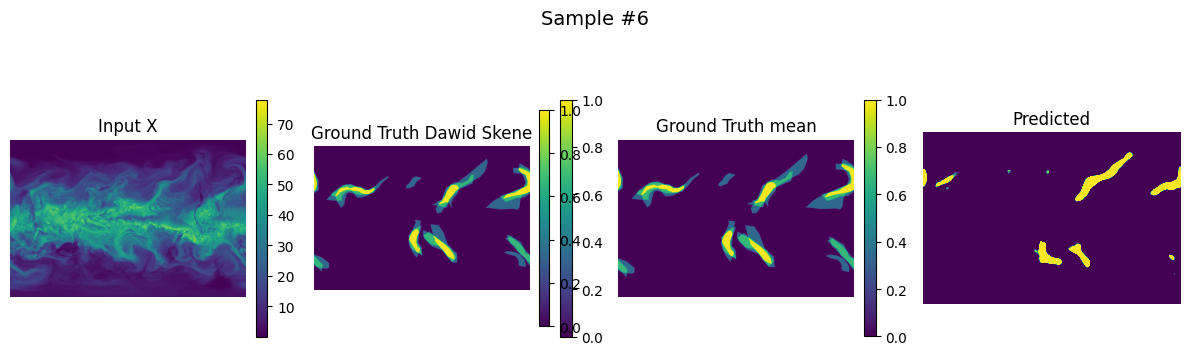

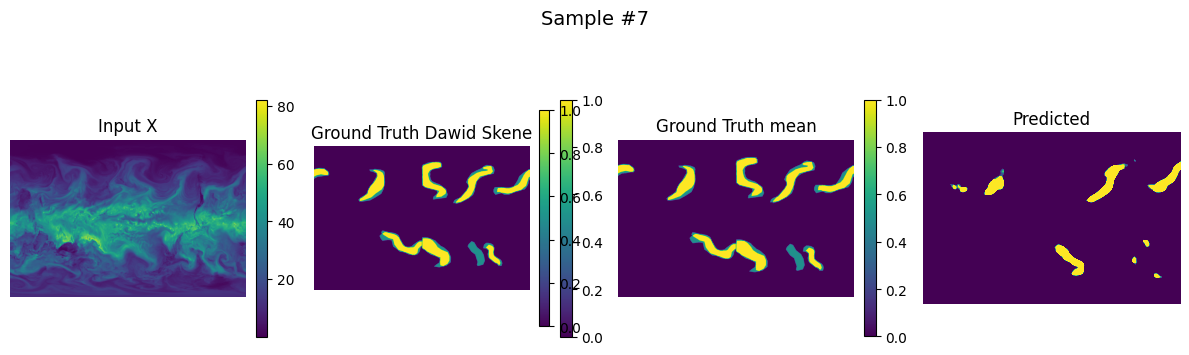

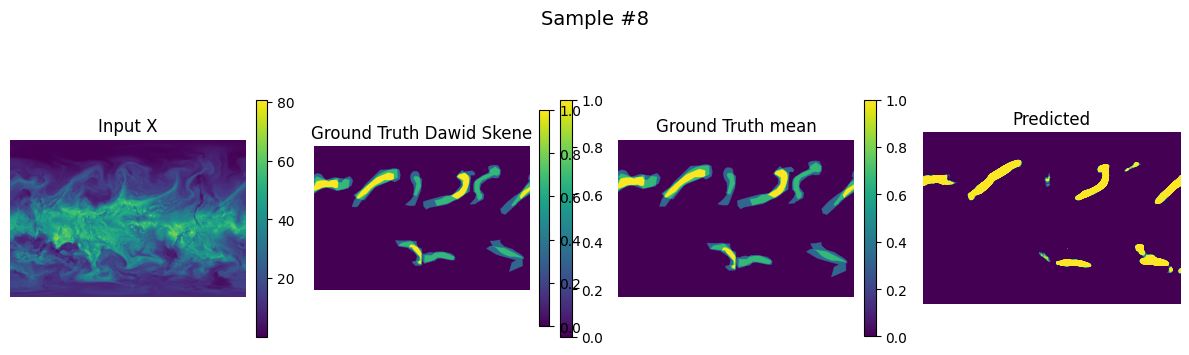

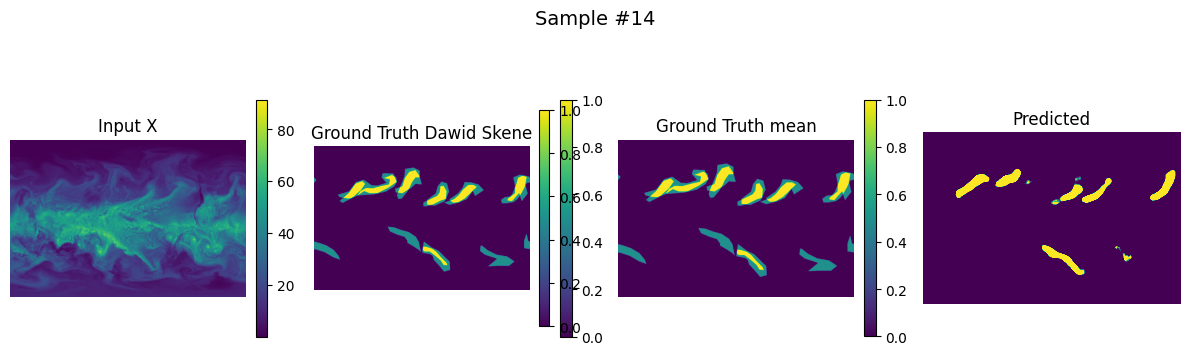

In [14]:
import matplotlib.pyplot as plt

# List of indices to plot
plot_idxs = [1, 5, 15, 6, 7,8,14]

# Assume these tensors are available:
#   X_test : torch.Tensor of shape [N, C, H, W]  (input feature, e.g. TMQ)
#   gt     : torch.Tensor of shape [N, 1, H, W]  (ground‐truth mask)
#   pred   : torch.Tensor of shape [N, 1, H, W]  (predicted probability map)
#
# If your variables have different names, just replace them accordingly.

for p in plot_idxs:
    # Extract numpy arrays for plotting
    x_img   = xvar[p, 0, :, :].cpu().numpy()    # input feature (single channel)
    gt_img  = gt[p,0,  :, :].cpu().numpy()     # ground truth mask
    gt_means =  y_means[p,0,  :, :].cpu().numpy()
    pr_img  = pred[p, 0,  :, :]   # predicted probability map

    fig, axes = plt.subplots(1, 4, figsize=(12, 4))
    fig.suptitle(f"Sample #{p}", fontsize=14)

    # 1) Input X
    im0 = axes[0].imshow(x_img, cmap="viridis")
    axes[0].set_title("Input X")
    axes[0].axis("off")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # 2) Ground-truth mask
    im1 = axes[1].imshow(gt_img, cmap="viridis", vmin=0, vmax=1)
    axes[1].set_title("Ground Truth Dawid Skene")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
     # 3) Ground-truth mask
    im1 = axes[2].imshow(gt_means, cmap="viridis", vmin=0, vmax=1)
    axes[2].set_title("Ground Truth mean")
    axes[2].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)


    # 4) Predicted probability
    im2 = axes[3].imshow(pr_img, cmap="viridis", vmin=0, vmax=1)
    axes[3].set_title("Predicted")
    axes[3].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# List of indices to plot
plot_idxs = [1, 5, 15, 6, 7, 8, 14]
n = len(plot_idxs)

# Assume these tensors/arrays exist:
#   x_test : torch.Tensor of shape [N, C, H, W]   (e.g. TMQ input)
#   gt_test: torch.Tensor of shape [N, 1, H, W]   (Dawid–Skene “ground truth”)
#   p_hat  : NumPy array of shape [N, H, W]       (predicted probability)
#
# (Adjust names if your variables differ.)

# Convert everything to NumPy ahead of time, so plotting is simpler:
x_arr  = x_test.cpu().numpy()    # shape [N, C, H, W]
gt_arr = gt_test.cpu().numpy()   # shape [N, 1, H, W]
# p_hat is already NumPy with shape [N, H, W]; if it’s a torch.Tensor, do p_hat = p_hat.cpu().numpy()

# Set up a grid with n rows and 3 columns
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n), constrained_layout=True)

for row_idx, p in enumerate(plot_idxs):
    #  -- panel 1: input X (take channel 0) --
    x_img = x_arr[p, 0, :, :]  # [H, W]
    ax0   = axes[row_idx, 0]
    im0   = ax0.imshow(x_img, cmap="viridis")
    ax0.set_title(f"Sample #{p}\nTMQ")
    ax0.axis("off")
    fig.colorbar(im0, ax=ax0, fraction=0.046, pad=0.04)

    #  -- panel 2: Dawid–Skene “ground truth” mask (binary 0/1) --
    gt_img = gt_arr[p, 0, :, :]  # [H, W]
    ax1    = axes[row_idx, 1]
    im1    = ax1.imshow(gt_img, cmap="viridis", vmin=0, vmax=1)
    ax1.set_title("Ground Truth (DS)")
    ax1.axis("off")
    fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    #  -- panel 3: predicted probability map (0..1) --
    pr_img = p_hat[p, :, :]      # [H, W]
    ax2    = axes[row_idx, 2]
    im2    = ax2.imshow(pr_img, cmap="viridis", vmin=0, vmax=1)
    ax2.set_title("Calibrated P(AR)")
    ax2.axis("off")
    fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# If axes is a 1×3 array (i.e. n=1), make sure axes is 2D:
if n == 1:
    axes = np.expand_dims(axes, axis=0)

plt.show()


NameError: name 'x_test' is not defined

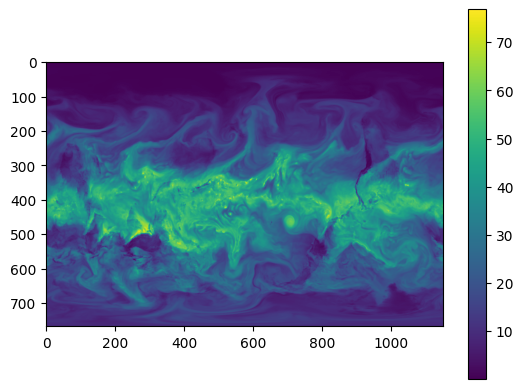

In [14]:
plt.imshow(xvar[13,0,:,:].cpu())
plt.colorbar()

Now we will fit a Bayesian logistic regression to calibrate the probabilities

In [15]:
true_mask = np.array(gt[:,0,:,:].cpu()>0.3)  # Size : (B, 768, 1152)
score_whole = np.array(pred.cpu()) # Size : (B, 1, 768, 1152)

In [108]:
score_whole.shape

(16, 1, 768, 1152)

In [16]:
# (Optional) Verify balance
uniq, counts = np.unique(true_mask, return_counts=True)
print("Class counts:", dict(zip(uniq, counts)))  # should be roughly equal

Class counts: {False: 13057103, True: 1098673}


In [17]:
N,H,W = true_mask.shape

In [18]:
z_test = score_whole.reshape(-1,1)         # (N·H·W,)
y_test = true_mask.reshape(-1,)          # same length

In [19]:
z_test.shape

(14155776, 1)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss


In [75]:
# --- 3) Fit Platt‐scaling logistic regression with balanced class weights ---
platt = LogisticRegression(
    penalty=None,          # no regularization
    solver='sag',
    class_weight= None, # rebalance automatically
    max_iter=1000,
    random_state=0
)
platt.fit(z_test, y_test)

LogisticRegression(max_iter=1000, penalty=None, random_state=0, solver='sag')

In [76]:
A_hat = platt.coef_[0, 0]      # slope
B_hat = platt.intercept_[0]    # intercept
print(f"Platt scaling: logit(p) = {A_hat:.4f} * raw_logit + {B_hat:.4f}")

Platt scaling: logit(p) = 0.5518 * raw_logit + -0.5908


In [55]:
platt

LogisticRegression(class_weight='balanced', max_iter=1000, penalty=None,
                   random_state=0, solver='sag')

In [72]:


# 1) Send your data to the GPU
#    z: logits, shape (Npix,)
#    y: labels 0/1, same shape
z_flat = jnp.asarray(z_test.astype("float32"))
y_flat = jnp.asarray(y_test.astype("int32"))

# 2) Define the Platt‐scaling model
def platt_model(z, y=None):
    A = numpyro.sample("A", dist.Normal(0.0, 5.0))
    B = numpyro.sample("B", dist.Normal(0.0, 5.0))
    logits = A * z + B
    numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
        
# 3) Set up and run NUTS on the GPU
kernel = NUTS(platt_model, target_accept_prob=0.8)
mcmc   = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=2)
rng_key = jax.random.PRNGKey(0)

mcmc.run(rng_key, z=z_flat, y=y_flat)
mcmc.print_summary()   # shows mean, sd, R-hat, ESS for A and B

# 4) Extract posterior samples of A, B
posterior = mcmc.get_samples()
A_draws   = posterior["A"]   # shape (1000,)
B_draws   = posterior["B"]

/tmp/ipykernel_3848860/2616537261.py:16: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc   = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=2)
sample: 100%|██████████| 2000/2000 [00:31<00:00, 64.20it/s, 3 steps of size 1.35e-01. acc. prob=0.89] 


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         A      1.10      0.00      1.10      1.09      1.10    403.52      1.00
         B      0.55      0.00      0.55      0.54      0.55    364.60      1.00

Number of divergences: 0


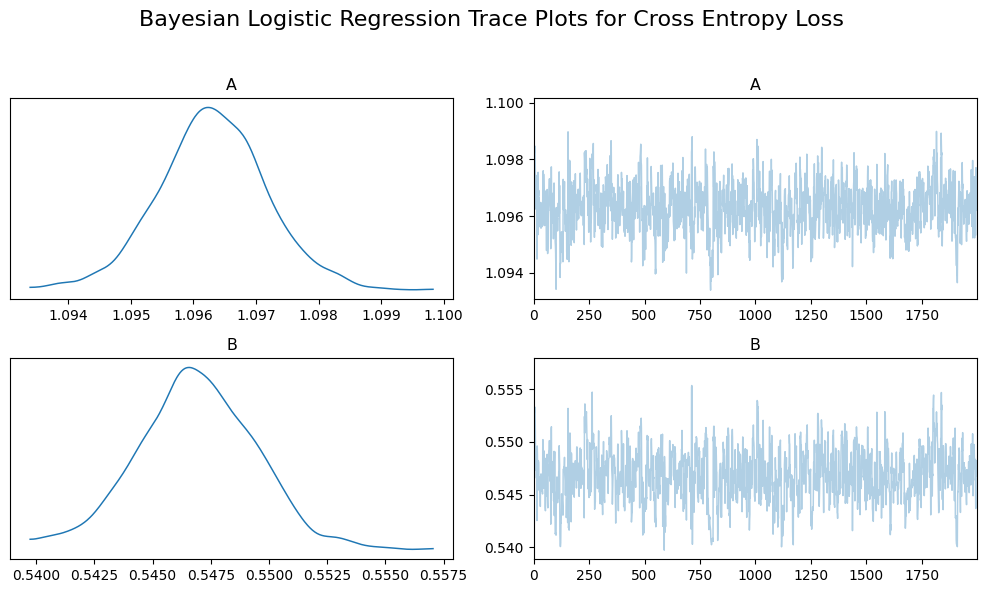

In [73]:
# 1) Extract posterior draws from your MCMC object
posterior = mcmc.get_samples()    # these are JAX DeviceArrays on GPU

# 2) Move A and B to NumPy on the host
A_np = np.asarray(posterior["A"])  # shape (n_samples,)
B_np = np.asarray(posterior["B"])

# 3) Create an ArviZ InferenceData from a Python dict
idata = az.from_dict(posterior={"A": A_np, "B": B_np})

# 4) Plot the trace
axes = az.plot_trace(idata, var_names=["A", "B"], figsize=(10, 6))

# 5) Add a super‐title and tighten layout
plt.suptitle("Bayesian Logistic Regression Trace Plots for Cross Entropy Loss", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [97]:
pred_test, gt_test, x_test,y_mean_test = predict_masks_gpu(
    ckpt_path = "/home/sbk29/data/github_AR/AR_detection/runs/arseg/unet_Jaccard_PL_new.pt",
    data_dir  = "/home/sbk29/data/AR/validation",
    label_dir = None,
    var_names = ["TMQ"],
    batch_size= 4,
    use_masks = "True",          # no human masks available
    device    = "cuda"          # keep everything on GPU
)

In [57]:
N,_,H,W = gt_test.shape

In [58]:
N

16

In [30]:
pred_test = np.array(pred_test.cpu()).reshape(-1)

AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [59]:
B_hat

3.106353904909475

In [98]:
p_hat = 1/(1 + np.exp(-((A_hat * pred_test) + B_hat)))

In [99]:
p_hat.shape

torch.Size([16, 1, 768, 1152])

In [100]:
p_hat = p_hat.reshape(N,H,W)
pred_test = pred_test.reshape(N,H,W)

In [79]:
pred_test2 = 1/(1 + np.exp(-(pred_test)))

In [80]:
pred_test2 = pred_test2.reshape(N,H,W)

In [81]:
p_hat.shape

torch.Size([16, 768, 1152])

In [82]:
predicted_mask = p_hat > 0.5

In [83]:
true_mask = gt_test[:,0,:,:].cpu()>0.3

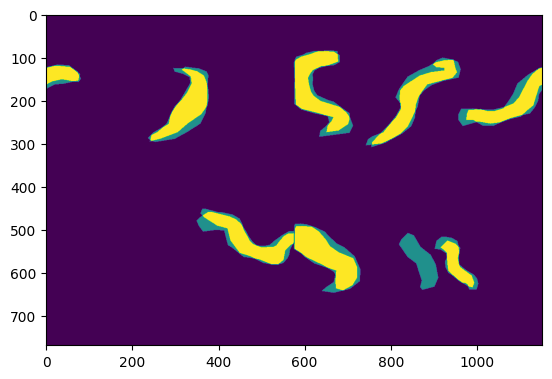

In [84]:
plt.imshow(gt_test[7,0,:,:])

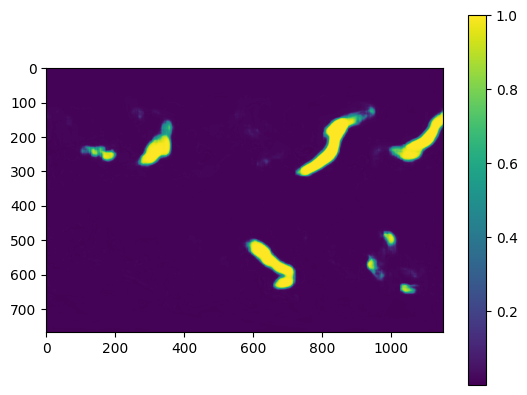

In [85]:
plt.imshow(pred_test2[7,:,:])
plt.colorbar()


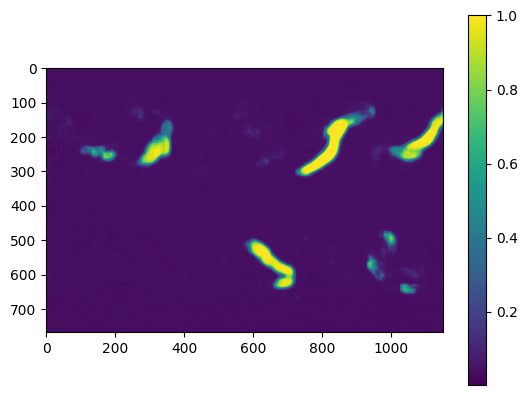

In [86]:
plt.imshow(p_hat[7,:,:])
plt.colorbar()

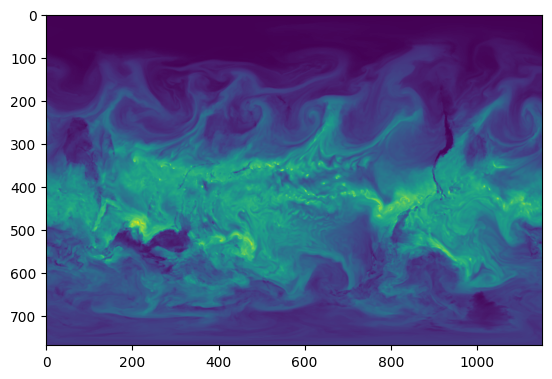

In [41]:
plt.imshow(x_test[4,0,:,:])

In [87]:
# Assuming true_mask has shape (61, 1, 768, 1152)
# and predicted_mask has shape (61, 768, 1152) (adjust indexing if needed)
num_samples = true_mask.shape[0]
scores = []

for i in range(num_samples):
    # Flatten the true mask and predicted mask for each sample.
    true_flat = true_mask[i, :, :].ravel()    # shape (768*1152,)
    pred_flat = predicted_mask[i, :, :].ravel()  # shape (768*1152,)
    pred_flat = pred_flat.ravel()
    
    # Compute the Jaccard score for the binary classification
    score = jaccard_score(true_flat, pred_flat)
    scores.append(score)

# Compute the average Jaccard score across all samples
average_jaccard = np.mean(scores)
print("Average Jaccard Score:", average_jaccard)

Average Jaccard Score: 0.31613519347950747


In [43]:
predicted_mask.shape

(16, 768, 1152)

Now we will calculate the Expected calibration error 

In [72]:
def calculate_ece(y_true, y_prob, n_bins=15):
    """
    Calculates the Expected Calibration Error (ECE) of a model.

    Args:
        y_true (np.array): Array of true labels (0s and 1s).
        y_prob (np.array): Array of predicted probabilities for the positive class.
        n_bins (int): The number of bins to use for the calculation.

    Returns:
        float: The Expected Calibration Error.
    """
    # Ensure inputs are numpy arrays
    y_true = np.array(y_true > 0.5)
    y_prob = np.array(y_prob)

    # Bin predictions by their confidence
    bin_limits = np.linspace(0, 1, n_bins + 1)
    # The last bin includes 1.0, so we use a small epsilon
    bin_indices = np.clip(np.digitize(y_prob, bin_limits[1:-1]), 0, n_bins - 1)

    ece = 0.0
    total_samples = len(y_true)

    for i in range(n_bins):
        # Find all samples that fall into the current bin
        in_bin = (bin_indices == i)
        
        # If the bin is not empty
        if np.any(in_bin):
            # Calculate the proportion of samples in this bin
            prop_in_bin = np.mean(in_bin)
            
            # Calculate the average confidence (mean of probabilities) in this bin
            confidence_in_bin = np.mean(y_prob[in_bin])
            
            # Calculate the accuracy (mean of true labels) in this bin
            accuracy_in_bin = np.mean(y_true[in_bin])
            
            # Add the bin's contribution to the ECE
            ece += prop_in_bin * np.abs(confidence_in_bin - accuracy_in_bin)

    return ece

In [92]:
def expected_calibration_error(pred_prob, y_true, M=5):
    # uniform binning approach with M number of bins
    bin_boundaries = np.linspace(0, 1, M + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]

    # get max probability per sample i
    confidences = pred_prob
    # get predictions from confidences (positional in this case)
    predicted_label = pred_prob > 0.5
    true_labels = y_true > 0.3

    # get a boolean list of correct/false predictions
    accuracies = predicted_label==true_labels

    ece = np.zeros(1)
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # determine if sample is in bin m (between bin lower &amp; upper)
        in_bin = np.logical_and(confidences > bin_lower.item(), confidences <= bin_upper.item())
        # can calculate the empirical probability of a sample falling into bin m: (|Bm|/n)
        prob_in_bin = in_bin.mean()

        if prob_in_bin.item() > 0:
            # get the accuracy of bin m: acc(Bm)
            accuracy_in_bin = accuracies[in_bin].mean()
            # get the average confidence of bin m: conf(Bm)
            avg_confidence_in_bin = confidences[in_bin].mean()
            # calculate |acc(Bm) - conf(Bm)| * (|Bm|/n) for bin m and add to the total ECE
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prob_in_bin
    return ece

In [93]:
expected_calibration_error(p_hat, gt_test[:,0,:,:])

RuntimeError: mean(): could not infer output dtype. Input dtype must be either a floating point or complex dtype. Got: Byte

In [88]:
calculate_ece(gt_test[:,0,:,:], pred_test2)

0.021235735940906494

In [89]:
calculate_ece(gt_test[:,0,:,:], p_hat)

0.03564609160336356

In [48]:
np.unique(gt_test)

array([0.  , 0.25, 0.5 , 0.75, 1.  ], dtype=float32)

In [70]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# 1) Suppose you have your features and binary targets:
#    X: array of shape (N, D)  e.g. z_flat.reshape(-1,1)
#    y: array of shape (N,)    e.g. y_flat

# Example:
X = z_flat.reshape(-1, 1)
y = y_flat
print(X.shape)

# 2) Fit logistic regression (no regularization, LBFGS solver)
model = LogisticRegression(
    penalty=None,
    solver='lbfgs',
    max_iter=1000,
    random_state=0
)
model.fit(X, y)

# 3) Inspect parameters
A_hat = model.coef_[0, 0]      # slope
B_hat = model.intercept_[0]    # intercept
print(f"Fitted:  logit(p) = {A_hat:.4f} * z + {B_hat:.4f}")

# 4) Predict probabilities and classes
p_hat     = model.predict_proba(X)[:, 1]   # P(y=1)
y_pred    = model.predict(X)               # 0 or 1

# 5) Simple performance metrics
print("AUC :", roc_auc_score(y, p_hat))
print("Acc :", accuracy_score(y, y_pred))


NameError: name 'z_flat' is not defined

In [14]:
# ------------------------------------------------------------
#  Plot TMQ · y_cons · SegNet probability   for every test slice
# ------------------------------------------------------------
import torch, matplotlib.pyplot as plt, pathlib
from tqdm import tqdm



# -------- user-editable paths ----------------------------------------------
weights   = "/home/sbk29/data/github_AR/AR_detection/u-net/runs/arseg/segnet_final.pt"          # trained weights (.pt)
data_dir  = "/home/sbk29/data/AR/test"      # folder with .nc test files
out_dir   = pathlib.Path("plots").expanduser()
batch_size = 1
device     = "cuda" if torch.cuda.is_available() else "cpu"
# ---------------------------------------------------------------------------

@torch.no_grad()
def plot_all(weights, data_dir, out_dir, batch_size=1, device="cuda"):
    ds = ARMultiAnnDataset(data_dir, ["TMQ"])            # dataset returns x_vars, y_list, y_cons
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False,
                                     collate_fn=collate_var, pin_memory=(device=="cuda"))

    seg = SegNet().to(device).eval()
    seg.load_state_dict(torch.load(weights, map_location=device))

    out_dir.mkdir(parents=True, exist_ok=True)

    for (x_vars, _, y_cons), (date_key, _) in tqdm(zip(dl, ds.samples),
                                                  total=len(ds), ncols=80):
        x_vars = x_vars.to(device)                  # [B,1,H,W]
        prob   = torch.sigmoid(seg(x_vars))[0, 0].cpu()   # (H,W)
        tmq    = x_vars[0, 0].cpu()
        cons   = y_cons[0, 0]                       # (H,W) float

        fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
        ax[0].imshow(tmq,  cmap="viridis"); ax[0].set_title("TMQ");          ax[0].axis("off")
        ax[1].imshow(cons, cmap="magma",  vmin=0, vmax=1); ax[1].set_title("y_Consolidated"); ax[1].axis("off")
        ax[2].imshow(prob, cmap="magma",  vmin=0, vmax=1); ax[2].set_title("U-Net prob"); ax[2].axis("off")

        fig.suptitle(f"Date: {date_key}", fontsize=13)
        fig.tight_layout()
        fig.savefig(out_dir / f"{date_key}.png", dpi=120)
        plt.close(fig)

    print("Saved plots to:", out_dir.resolve())

# -------- run ----------------------------------------------------------------
plot_all(weights, data_dir, out_dir, batch_size, device)


/tmp/ipykernel_1590872/443872827.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  seg.load_state_dict(torch.load(weights, map_location=device))
100%|████████████████████

Saved plots to: /mnt/pixstor/data/sbk29/github_AR/AR_detection/u-net/plots


In [18]:


# --------- user-editable paths ------------------------------------------------
weights   = "/home/sbk29/data/github_AR/AR_detection/u-net/runs/arseg/segnet_final.pt" 
data_dir  = "/home/sbk29/data/AR/test"
out_dir   = pathlib.Path("plots_with_bg")
bg_img_path = "/home/sbk29/data/github_AR/AR_detection/climatenet/bluemarble/BM.jpeg"   # must match TMQ resolution
batch_size = 1
device     = "cuda" if torch.cuda.is_available() else "cpu"
# ------------------------------------------------------------------------------

@torch.no_grad()
def plot_all(weights, data_dir, out_dir, bg_img_path, batch_size=1, device="cuda"):
    ds = ARMultiAnnDataset(data_dir, ["TMQ"])
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False,
                                     collate_fn=collate_var, pin_memory=(device=="cuda"))

    seg = SegNet().to(device).eval()
    seg.load_state_dict(torch.load(weights, map_location=device))

    bg = mpimg.imread(bg_img_path)   # should be (768, 1152[, 3])
    out_dir.mkdir(parents=True, exist_ok=True)

    for (x_vars, _, y_cons), (date_key, _) in tqdm(zip(dl, ds.samples), total=len(ds), ncols=80):
        x_vars = x_vars.to(device)
        prob   = torch.sigmoid(seg(x_vars))[0, 0].cpu()
        tmq    = x_vars[0, 0].cpu()
        cons   = y_cons[0, 0]

        fig, ax = plt.subplots(1, 3, figsize=(15, 4))

        # --- TMQ: standalone + colorbar
        im0 = ax[0].imshow(tmq, cmap="viridis")
        c0 = fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
        c0.set_label("TMQ")
        ax[0].set_title("TMQ"); ax[0].axis("off")

        # --- y_cons overlaid on background
        ax[1].imshow(bg, cmap='gray', alpha=1.0)
        im1 = ax[1].imshow(cons, cmap="magma", vmin=0, vmax=1, alpha=0.6)
        c1 = fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
        c1.set_label("y_cons")
        ax[1].set_title("y_cons"); ax[1].axis("off")

        # --- prediction overlaid on background
        ax[2].imshow(bg, cmap='gray', alpha=1.0)
        im2 = ax[2].imshow(prob, cmap="magma", vmin=0, vmax=1, alpha=0.6)
        c2 = fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)
        c2.set_label("prob")
        ax[2].set_title("SegNet prob"); ax[2].axis("off")

        fig.suptitle(f"Date: {date_key}", fontsize=13)
        fig.tight_layout()
        fig.savefig(out_dir / f"{date_key}.png", dpi=120)
        plt.close(fig)

    print("✅ Saved plots to:", out_dir.resolve())

# ---------- Run it -------------------
plot_all(weights, data_dir, out_dir, bg_img_path, batch_size, device)


/tmp/ipykernel_1590872/3008682495.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  seg.load_state_dict(torch.load(weights, map_location=device))
100%|███████████████████

✅ Saved plots to: /mnt/pixstor/data/sbk29/github_AR/AR_detection/u-net/plots_with_bg


In [6]:
from procrustes_loss_new import ProcrustesLossBag

In [17]:


# ---------- CONFIG ---------------------------------------------------
data_dir = "/home/sbk29/data/AR/train"
var_names = ["TMQ"]
batch_size = 8
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- LOAD DATA ------------------------------------------------
ds = ARMultiAnnDataset(data_dir, var_names)
loader = torch.utils.data.DataLoader(ds, batch_size=batch_size,
                                     shuffle=True, collate_fn=collate_var)

# ---------- INIT LOSS ------------------------------------------------
loss_fn = ProcrustesLossBag(alpha=2.0)

# ---------- FETCH A BATCH --------------------------------------------
x_vars, y_lists, y_cons = next(iter(loader))

# To GPU (only x and y_cons for sanity)
x_vars = x_vars.to(device)
y_cons = y_cons.to(device)

# Dummy prediction (simulate a trained model output)
logits = torch.rand_like(y_cons) * 5 - 2.5   # logits in range [-2.5, 2.5]
probs = torch.sigmoid(logits)

# ---------- COMPUTE LOSS ---------------------------------------------
loss = loss_fn(probs, y_cons)

# # ---------- VISUALIZE ------------------------------------------------
# import pandas as pd
# import ace_tools as tools

# # Show sample stats
# sample_stats = []
# for i in range(batch_size):
#     stats = {
#         "Index": i,
#         "y_cons min": float(y_cons[i,0].min()),
#         "y_cons max": float(y_cons[i,0].max()),
#         "prob min": float(probs[i,0].min()),
#         "prob max": float(probs[i,0].max()),
#     }
#     sample_stats.append(stats)

# df = pd.DataFrame(sample_stats)
# tools.display_dataframe_to_user(name="Sample Sanity Check", dataframe=df)

# Also return loss value
loss.item()


11146.603515625

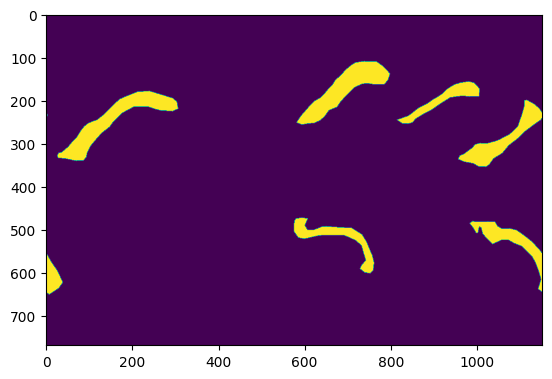

In [13]:
plt.imshow(y_cons[1,0,:,:].cpu())

tensor(9540.6045, device='cuda:0')

torch.Size([2, 12, 768, 1152])


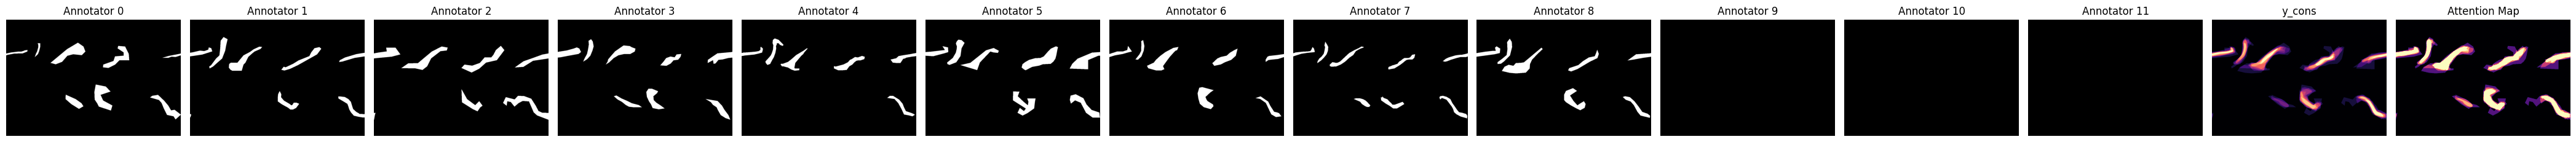

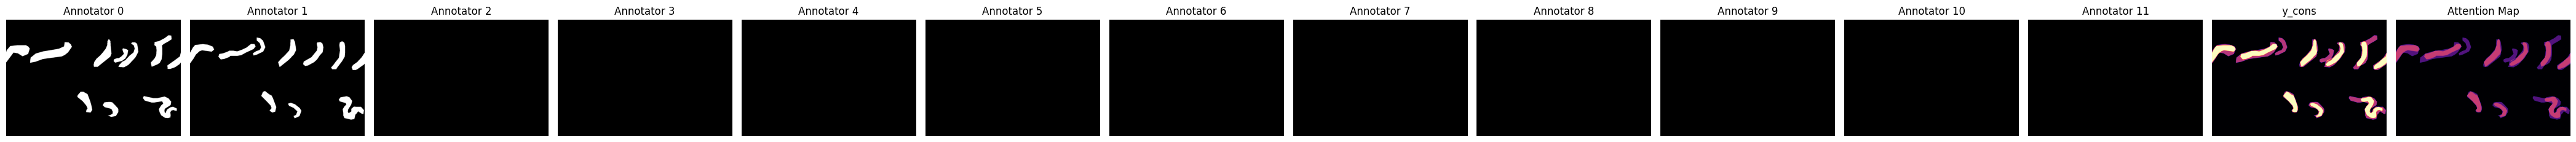

In [6]:
# import torch
# import matplotlib.pyplot as plt
# from torch.utils.data import DataLoader
# from train_dataset import ARMultiAnnDataset, collate_var
from attention import AnnotatorDualAttention
import pandas as pd
import ace_tools_open as tools

# ---------- CONFIG ---------------------------------------------------
data_dir = "/home/sbk29/data/AR/train"
var_names = ["TMQ"]
batch_size = 2
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- LOAD DATA ------------------------------------------------
ds = ARMultiAnnDataset(data_dir, var_names)
loader = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate_var)

# ---------- SETUP ATTENTION MODULE -----------------------------------
N_max = ds.real_max_ann
attn_mod = AnnotatorDualAttention(n_annotators=N_max).to(device)

# ---------- FETCH ONE BATCH ------------------------------------------
x_vars, y_lists, y_cons = next(iter(loader))
B, C, H, W = x_vars.shape

# Build y_stack [B, N_max, H, W]
y_stack = []
for lst in y_lists:
    if len(lst) < N_max:
        pad = [torch.zeros_like(lst[0])]*(N_max - len(lst))
        lst = lst + pad
    y_stack.append(torch.stack(lst, dim=0))
y_stack = torch.stack(y_stack, dim=0).to(device)
y_stack = y_stack.squeeze(2) 
print(y_stack.shape)

# ---------- COMPUTE ATTENTION ----------------------------------------
attn_map, annotator_weights = attn_mod(y_stack)  # attn_map: [B,1,H,W], weights: [B,N_max]

# # ---------- SANITY CHECK TABLE --------------------------------------
# stats = []
# for b in range(B):
#     row = {"Sample": b}
#     for i in range(N_max):
#         row[f"Annotator_{i}_weight"] = float(annotator_weights[b,i].cpu())
#     stats.append(row)
# df = pd.DataFrame(stats)
# tools.display_dataframe_to_user(name="Annotator Weights", dataframe=df)

# ---------- VISUALIZATION -------------------------------------------
for b in range(B):
    fig, axes = plt.subplots(1, N_max + 2, figsize=(3*(N_max+2), 3))

    # Show each annotator mask
    for i in range(N_max):
        axes[i].imshow(y_stack[b, i].cpu(), cmap="gray")
        axes[i].set_title(f"Annotator {i}")
        axes[i].axis("off")

    # Show consensus mask
    axes[N_max].imshow(y_cons[b, 0].cpu(), cmap="magma", vmin=0, vmax=1)
    axes[N_max].set_title("y_cons")
    axes[N_max].axis("off")

    # Show attention map
    axes[N_max + 1].imshow(attn_map[b, 0].detach().cpu(), cmap="magma", vmin=0, vmax=1)
    axes[N_max + 1].set_title("Attention Map")
    axes[N_max + 1].axis("off")

    plt.tight_layout()
    plt.show()

In [8]:
annotator_weights


tensor([[0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
         0.5000, 0.5000, 0.5000],
        [0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000, 0.5000,
         0.5000, 0.5000, 0.5000]], device='cuda:0', grad_fn=<SigmoidBackward0>)


--- Processing Image 1/188 ---


ValueError: Image 0: Unexpected format in list of rater masks.

In [3]:
ds = ARMultiAnnDataset("/home/sbk29/data/AR/train", ["TMQ"]) 

In [4]:
np.array(ds[12][1]).shape

(4, 1, 768, 1152)

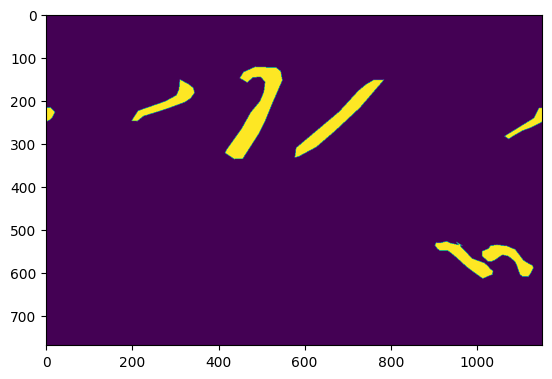

In [ ]:
plt.imshow(np.array(ds[12][1]))

Using user's ARMultiAnnDataset with 188 samples.

--- Processing Image 13/188 ---
Image dimensions: (768, 1152), Number of raters: 4
  Gibbs sampler initialized L_current randomly.
Starting Gibbs Sampler for an image (10 iterations)...
    Iteration 1/10
    Iteration 2/10
    Iteration 3/10
    Iteration 4/10
    Iteration 5/10
    Iteration 6/10
    Iteration 7/10
    Iteration 8/10
    Iteration 9/10
  Gibbs Sampler Finished for this image.
No MCMC samples collected for image 13 after burn-in.

--- Overall Processing Complete ---

Visualizing results for Image 1 (original index 0)


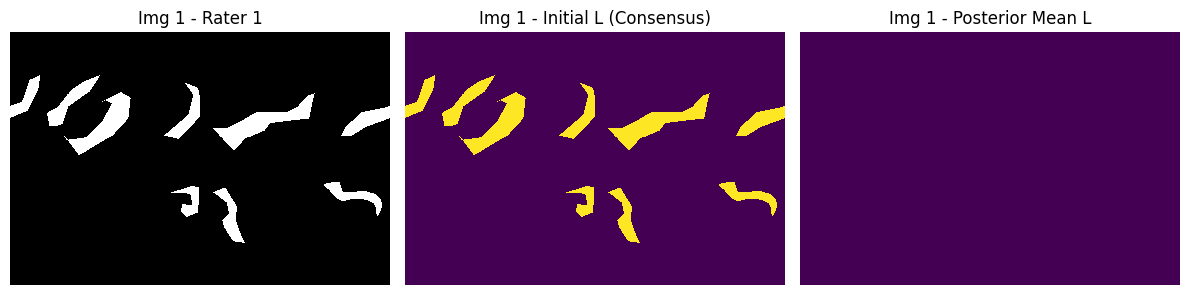

No rater parameters estimated for Image 1


In [ ]:
import numpy as np
from scipy.stats import beta, bernoulli
import matplotlib.pyplot as plt
import torch # Assuming this is used in your Dataset
# --- USER: Insert your ARMultiAnnDataset class definition and its dependencies here ---
from pathlib import Path
import glob
import xarray as xr # If used in _load_nc
import re
from typing   import List, Tuple

FNAME_RE = re.compile(r"data-(\d{4}-\d{2}-\d{2})-.*?_(\d+)\.nc$")

class ARMultiAnnDataset(torch.utils.data.Dataset):
    def __init__(self, root: str | Path, var_names: List[str]):
        super().__init__()
        self.root, self.var_names = Path(root), var_names

        by_date = {}
        for f in glob.glob(str(self.root / "*.nc")):
            m = FNAME_RE.search(Path(f).name)
            if m:
                by_date.setdefault(m.group(1), {})[int(m.group(2))] = Path(f)

        self.samples = sorted(by_date.items())
        self.real_max_ann = max(len(d) for _,d in self.samples)

    def _load_nc(self, path: Path) -> Tuple[torch.Tensor, torch.Tensor]:
        ds = xr.open_dataset(path, engine="netcdf4")

        # squeeze() drops ANY singleton dimension, e.g. the leading "time=1"
        vars_arr = [
            torch.as_tensor(ds[v].values).squeeze()     # (H, W) after squeeze
            for v in self.var_names
        ]
        x = torch.stack(vars_arr).float()               # [C, H, W]
        
        raw = torch.as_tensor(ds["LABELS"].values).squeeze()
        y   = (raw == 2).float().unsqueeze(0) 

        # y = torch.as_tensor(ds["LABELS"].values).squeeze().unsqueeze(0).float()
        ds.close()
        return x, y

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        _, ann_map = self.samples[idx]
        x_vars, y_list = None, []
        for p in ann_map.values():
            x, y = self._load_nc(p)
            if x_vars is None: x_vars = x
            y_list.append(y)
        y_cons = torch.stack(y_list).mean(0)
        return x_vars, y_list, y_cons      # variable-length list

def collate_var(batch):
    xs, y_lists, y_cons = zip(*batch)
    return torch.stack(xs), list(y_lists), torch.stack(y_cons)

# --- End USER Dataset Definition ---


# --- Paste the MCMC helper functions (unchanged from previous versions) ---
BETA_PRIOR_SE_A, BETA_PRIOR_SE_B = 1, 1
BETA_PRIOR_SP_A, BETA_PRIOR_SP_B = 1, 1
LAMBDA_SMOOTH = 1.0

def update_rater_performance(L_current, rater_mask_k):
    # (Identical to previous version)
    N_11 = np.sum((L_current == 1) & (rater_mask_k == 1))
    N_10 = np.sum((L_current == 1) & (rater_mask_k == 0))
    N_00 = np.sum((L_current == 0) & (rater_mask_k == 0))
    N_01 = np.sum((L_current == 0) & (rater_mask_k == 1))
    se_k_posterior_a = BETA_PRIOR_SE_A + N_11
    se_k_posterior_b = BETA_PRIOR_SE_B + N_10
    new_se_k = np.clip(beta.rvs(se_k_posterior_a, se_k_posterior_b), 0.01, 0.99)
    sp_k_posterior_a = BETA_PRIOR_SP_A + N_00
    sp_k_posterior_b = BETA_PRIOR_SP_B + N_01
    new_sp_k = np.clip(beta.rvs(sp_k_posterior_a, sp_k_posterior_b), 0.01, 0.99)
    return new_se_k, new_sp_k

def get_neighbors(r, c, img_dims, connectivity=8): # Defaulting to 8 now, or you can pass it
    neighbors = []
    # Orthogonal neighbors (4-connectivity)
    if r > 0: neighbors.append((r - 1, c))
    if r < img_dims[0] - 1: neighbors.append((r + 1, c))
    if c > 0: neighbors.append((r, c - 1))
    if c < img_dims[1] - 1: neighbors.append((r, c + 1))

    # Diagonal neighbors (add if 8-connectivity is requested)
    if connectivity == 8:
        if r > 0 and c > 0: neighbors.append((r - 1, c - 1))                 # Top-left
        if r > 0 and c < img_dims[1] - 1: neighbors.append((r - 1, c + 1))     # Top-right
        if r < img_dims[0] - 1 and c > 0: neighbors.append((r + 1, c - 1))     # Bottom-left
        if r < img_dims[0] - 1 and c < img_dims[1] - 1: neighbors.append((r + 1, c + 1)) # Bottom-right
    return neighbors

def calculate_log_prob_L_pixel(r, c, L_val, L_current, rater_masks_all,
                               se_raters, sp_raters, img_dims):
    # (Identical to previous version, including the placeholder for advanced shape prior)
    log_p = 0.0
    for k in range(len(rater_masks_all)): # rater_masks_all is list of 2D np arrays
        R_kij = rater_masks_all[k][r, c]
        se_k = se_raters[k]
        sp_k = sp_raters[k]
        # Add small epsilon to log arguments to prevent log(0)
        eps = 1e-9
        if L_val == 1:
            if R_kij == 1: log_p += np.log(se_k if se_k > eps else eps)
            else: log_p += np.log((1 - se_k) if (1 - se_k) > eps else eps)
        else:
            if R_kij == 0: log_p += np.log(sp_k if sp_k > eps else eps)
            else: log_p += np.log((1 - sp_k) if (1 - sp_k) > eps else eps)

    smoothness_penalty = 0
    neighbors = get_neighbors(r, c, img_dims, connectivity=4)
    for nr, nc in neighbors:
        if L_val != L_current[nr, nc]:
            smoothness_penalty += 1
    log_p += -LAMBDA_SMOOTH * smoothness_penalty

    # --- Placeholder for Advanced "Long, Narrow, Elongated" Shape Prior ---
    # log_p_shape = calculate_log_prob_advanced_shape(L_current_with_proposed_L_ij, r, c, L_val)
    # log_p += log_p_shape
    # This function would be complex, operating on connected components of a temporary L.
    return log_p

# --- Modified gibbs_sampler to accept L_initial ---
def gibbs_sampler(rater_masks_all, img_dims, n_raters,
                  L_initial=None, # New parameter for initial L
                  n_iter=100, burn_in=20):
    # Initialization of L_current
    if L_initial is not None and L_initial.shape == img_dims:
        L_current = L_initial.copy().astype(int) # Ensure it's int
        print("  Gibbs sampler initialized L_current from provided L_initial.")
    else:
        L_current = np.random.randint(0, 2, size=img_dims) # Default if no L_initial
        if L_initial is not None:
            print(f"  L_initial shape mismatch ({L_initial.shape} vs {img_dims}) or None. Using random L_current.")
        else:
            print("  Gibbs sampler initialized L_current randomly.")


    se_raters = [beta.rvs(BETA_PRIOR_SE_A, BETA_PRIOR_SE_B) for _ in range(n_raters)]
    sp_raters = [beta.rvs(BETA_PRIOR_SP_A, BETA_PRIOR_SP_B) for _ in range(n_raters)]
    L_samples = []
    se_samples = [[] for _ in range(n_raters)]
    sp_samples = [[] for _ in range(n_raters)]

    print(f"Starting Gibbs Sampler for an image ({n_iter} iterations)...")
    for iteration in range(n_iter):
        if iteration > 0 and iteration % (n_iter // 10 if n_iter >=10 else 1) == 0 :
             print(f"    Iteration {iteration}/{n_iter}")

        # 1. Update rater performance parameters
        for k in range(n_raters):
            se_raters[k], sp_raters[k] = update_rater_performance(L_current, rater_masks_all[k])

        # 2. Update latent mask L (pixel by pixel)
        pixel_indices = [(r, c) for r in range(img_dims[0]) for c in range(img_dims[1])]
        np.random.shuffle(pixel_indices)
        for r, c in pixel_indices:
            log_p_L_is_1 = calculate_log_prob_L_pixel(r, c, 1, L_current, rater_masks_all,
                                                    se_raters, sp_raters, img_dims)
            log_p_L_is_0 = calculate_log_prob_L_pixel(r, c, 0, L_current, rater_masks_all,
                                                    se_raters, sp_raters, img_dims)
            max_log_p = max(log_p_L_is_1, log_p_L_is_0)
            # Check for NaN or very large/small numbers before exp
            if np.isneginf(max_log_p): # both probs are zero
                prob_L_is_1_normalized = 0.5 # or other default
            else:
                p_L_is_1 = np.exp(log_p_L_is_1 - max_log_p)
                p_L_is_0 = np.exp(log_p_L_is_0 - max_log_p)
                sum_p = p_L_is_1 + p_L_is_0
                if sum_p > 0:
                    prob_L_is_1_normalized = p_L_is_1 / sum_p
                else: # both are zero after exp
                    prob_L_is_1_normalized = 0.5


            L_current[r, c] = bernoulli.rvs(prob_L_is_1_normalized)

        if iteration >= burn_in:
            L_samples.append(L_current.copy())
            for k in range(n_raters):
                se_samples[k].append(se_raters[k])
                sp_samples[k].append(sp_raters[k])
    print("  Gibbs Sampler Finished for this image.")
    return L_samples, se_samples, sp_samples
# --- End of MCMC functions ---


# --- Main Execution with User's PyTorch Dataset ---
if __name__ == '__main__':
    # --- USER: Instantiate Your PyTorch Dataset ---
    # You need to have your ARMultiAnnDataset class definition above this block
    # and provide the correct `root` and `var_names`.
    my_ar_dataset_instance = None
    try:
        # Replace with your actual dataset path and var_names
        # from pathlib import Path # Ensure Path is imported if used in ARMultiAnnDataset
        ROOT_PATH_ACTUAL = "/home/sbk29/data/AR/train"
        VAR_NAMES_ACTUAL = ["TMQ"]
        my_ar_dataset_instance = ARMultiAnnDataset(root=ROOT_PATH_ACTUAL, var_names=VAR_NAMES_ACTUAL)
        if len(my_ar_dataset_instance) == 0:
            print("User dataset initialized but found 0 samples. Check dataset path and logic.")
            my_ar_dataset_instance = None
        pass # This line should be replaced by your dataset instantiation
    except Exception as e:
        print(f"Could not instantiate user's ARMultiAnnDataset: {e}. ")
        my_ar_dataset_instance = None

    if my_ar_dataset_instance is None:
        print("Using placeholder data as ARMultiAnnDataset was not successfully instantiated or is empty.")
        # Fallback to placeholder data for demonstration
        num_dataset_images = 2
        IMG_DIMS_DATASET = (25, 35) # H, W
        N_RATERS_DATASET_MIN = 2
        N_RATERS_DATASET_MAX = 4
        placeholder_dataset = []
        for i in range(num_dataset_images):
            x_vars_img_ph = torch.randn(2, IMG_DIMS_DATASET[0], IMG_DIMS_DATASET[1]) # Dummy C, H, W
            num_raters_for_this_image = np.random.randint(N_RATERS_DATASET_MIN, N_RATERS_DATASET_MAX + 1)
            y_list_img_tensors_ph = []
            for _ in range(num_raters_for_this_image):
                # Create a somewhat elongated structure for dummy rater masks
                mask = torch.zeros(1, IMG_DIMS_DATASET[0], IMG_DIMS_DATASET[1])
                row_start = np.random.randint(0, IMG_DIMS_DATASET[0] // 2)
                row_end = row_start + np.random.randint(IMG_DIMS_DATASET[0] // 4, IMG_DIMS_DATASET[0] // 2)
                col_start = np.random.randint(0, IMG_DIMS_DATASET[1] // 2)
                col_end = col_start + np.random.randint(IMG_DIMS_DATASET[1] // 4, IMG_DIMS_DATASET[1] // 2)
                mask[0, row_start:min(row_end, IMG_DIMS_DATASET[0]), col_start:min(col_end, IMG_DIMS_DATASET[1])] = (torch.rand_like(mask[0, row_start:min(row_end, IMG_DIMS_DATASET[0]), col_start:min(col_end, IMG_DIMS_DATASET[1])]) > 0.3).float()
                y_list_img_tensors_ph.append(mask)

            y_cons_img_ph = torch.stack(y_list_img_tensors_ph).mean(0) if y_list_img_tensors_ph else torch.zeros(1, IMG_DIMS_DATASET[0], IMG_DIMS_DATASET[1])
            placeholder_dataset.append((x_vars_img_ph, y_list_img_tensors_ph, y_cons_img_ph))
        data_source = placeholder_dataset
        data_source_len = len(placeholder_dataset)
        data_source_getitem = lambda idx_ph: placeholder_dataset[idx_ph] # Simple lambda for list access
        print(f"Placeholder dataset created with {data_source_len} images.")
    else:
        data_source = my_ar_dataset_instance
        data_source_len = len(my_ar_dataset_instance)
        data_source_getitem = lambda idx_ds: my_ar_dataset_instance[idx_ds] # Direct dataset access
        print(f"Using user's ARMultiAnnDataset with {data_source_len} samples.")
    # --- End Dataset Handling ---

    N_MCMC_ITER = 20   # MCMC iterations per image
    N_MCMC_BURN_IN = 10 # MCMC burn-in per image

    all_estimated_L_masks_posterior_mean = []
    all_estimated_rater_params_per_image = []

    for i in [12]:
        print(f"\n--- Processing Image {i+1}/{data_source_len} ---")
        try:
            x_vars_img_tensor, y_list_img_tensors, y_cons_img_tensor = data_source_getitem(i)
        except Exception as e:
            print(f"Error getting item {i} from dataset: {e}. Skipping this item.")
            all_estimated_L_masks_posterior_mean.append(None)
            all_estimated_rater_params_per_image.append(None)
            continue

        # --- Data Preprocessing Step (Crucial) ---
        if not y_list_img_tensors: # Check if y_list is empty
            print(f"Image {i+1}: y_list is empty (no rater annotations). Skipping MCMC for this image.")
            all_estimated_L_masks_posterior_mean.append(None) # Or a mask of zeros if preferred
            all_estimated_rater_params_per_image.append([]) # No raters to estimate
            continue

        rater_masks_list_np = []
        if not isinstance(y_list_img_tensors, list): # Should be a list from your __getitem__
            print(f"Warning: Image {i+1}: y_list_img_tensors is not a list (type: {type(y_list_img_tensors)}). Attempting to process if iterable.")
            # Potentially add logic here if it's a stacked tensor instead of a list of tensors

        for r_idx, rater_mask_tensor in enumerate(y_list_img_tensors):
            if not torch.is_tensor(rater_mask_tensor):
                print(f"Warning: Image {i+1}, Rater {r_idx}: Mask is not a PyTorch tensor (type: {type(rater_mask_tensor)}). Skipping this rater's mask.")
                continue
            if rater_mask_tensor.ndim != 3 or rater_mask_tensor.shape[0] != 1:
                print(f"Warning: Image {i+1}, Rater {r_idx}: Mask shape is {rater_mask_tensor.shape} (expected [1, H, W]). Skipping this rater's mask.")
                continue
            # Squeeze channel dim, convert to CPU NumPy array, ensure int type
            rater_mask_np = rater_mask_tensor.squeeze(0).cpu().numpy().astype(int)
            rater_masks_list_np.append(rater_mask_np)

        if not rater_masks_list_np: # Check if list is empty after potential skips
            print(f"Image {i+1}: No valid rater masks found after preprocessing. Skipping MCMC for this image.")
            all_estimated_L_masks_posterior_mean.append(None)
            all_estimated_rater_params_per_image.append([])
            continue
        # --- End Data Preprocessing ---

        current_img_dims = rater_masks_list_np[0].shape # (H, W)
        current_n_raters = len(rater_masks_list_np)
        print(f"Image dimensions: {current_img_dims}, Number of raters: {current_n_raters}")

        # Prepare L_initial from y_cons_img_tensor ([1, H, W] tensor)
        L_initial_np = y_cons_img_tensor.squeeze(0).cpu().numpy()
        # Binarize the consensus mask (it might be float from the mean operation)
        L_initial_binary_np = (L_initial_np > 0.5).astype(int)

        # --- Call Gibbs Sampler ---
        L_samples, se_samples_img, sp_samples_img = gibbs_sampler(
            rater_masks_list_np, current_img_dims, current_n_raters,
            L_initial=L_initial_binary_np,
            n_iter=N_MCMC_ITER, burn_in=N_MCMC_BURN_IN
        )

        if L_samples:
            L_posterior_mean = np.mean(L_samples, axis=0)
            all_estimated_L_masks_posterior_mean.append(L_posterior_mean)

            estimated_se_img = [np.mean(s) for s in se_samples_img]
            estimated_sp_img = [np.mean(s) for s in sp_samples_img]
            rater_params_current_img = [{'Se': se_k, 'Sp': sp_k} for se_k, sp_k in zip(estimated_se_img, estimated_sp_img)]
            all_estimated_rater_params_per_image.append(rater_params_current_img)

            print(f"Finished processing image {i+1}.")
            if rater_params_current_img:
                 print(f"  Est. Se (Rater 1): {rater_params_current_img[0]['Se']:.3f}, Est. Sp (Rater 1): {rater_params_current_img[0]['Sp']:.3f}")
        else:
            print(f"No MCMC samples collected for image {i+1} after burn-in.")
            all_estimated_L_masks_posterior_mean.append(np.zeros(current_img_dims)) # Store a blank mask or None
            all_estimated_rater_params_per_image.append([])

    print("\n--- Overall Processing Complete ---")

    # --- Visualization for the first successfully processed image ---
    first_successful_idx = -1
    for idx, l_mask in enumerate(all_estimated_L_masks_posterior_mean):
        if l_mask is not None:
            first_successful_idx = idx
            break

    if first_successful_idx != -1:
        print(f"\nVisualizing results for Image {first_successful_idx + 1} (original index {first_successful_idx})")
        # Get the original data again for plotting
        _, y_list_tensors_plot, y_cons_tensor_plot = data_source_getitem(first_successful_idx)
        rater_masks_plot_np = [m.squeeze(0).cpu().numpy() for m in y_list_tensors_plot]

        num_plot_cols = len(rater_masks_plot_np) + 2 # Rater masks + Consensus + Posterior L
        fig_width = 4 * num_plot_cols
        fig_height = 4

        fig, axes = plt.subplots(1, num_plot_cols, figsize=(fig_width, fig_height))
        if num_plot_cols == 1: axes = [axes] # Ensure axes is iterable

        for k_plot in range(len(rater_masks_plot_np)):
            axes[k_plot].imshow(rater_masks_plot_np[k_plot], cmap='gray', interpolation='nearest')
            axes[k_plot].set_title(f"Img {first_successful_idx+1} - Rater {k_plot+1}")
            axes[k_plot].axis('off')

        axes[len(rater_masks_plot_np)].imshow(y_cons_tensor_plot.squeeze(0).cpu().numpy(), cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
        axes[len(rater_masks_plot_np)].set_title(f"Img {first_successful_idx+1} - Initial L (Consensus)")
        axes[len(rater_masks_plot_np)].axis('off')


        axes[len(rater_masks_plot_np)+1].imshow(all_estimated_L_masks_posterior_mean[first_successful_idx], cmap='viridis', vmin=0, vmax=1, interpolation='nearest')
        axes[len(rater_masks_plot_np)+1].set_title(f"Img {first_successful_idx+1} - Posterior Mean L")
        axes[len(rater_masks_plot_np)+1].axis('off')

        plt.tight_layout()
        plt.show()

        if all_estimated_rater_params_per_image[first_successful_idx]:
            print(f"\nEstimated Rater Parameters for Image {first_successful_idx + 1}:")
            for r_idx, params in enumerate(all_estimated_rater_params_per_image[first_successful_idx]):
                print(f"  Rater {r_idx+1}: Se={params['Se']:.3f}, Sp={params['Sp']:.3f}")
        else:
            print(f"No rater parameters estimated for Image {first_successful_idx + 1}")
    else:
        print("No images were successfully processed to show visualization.")

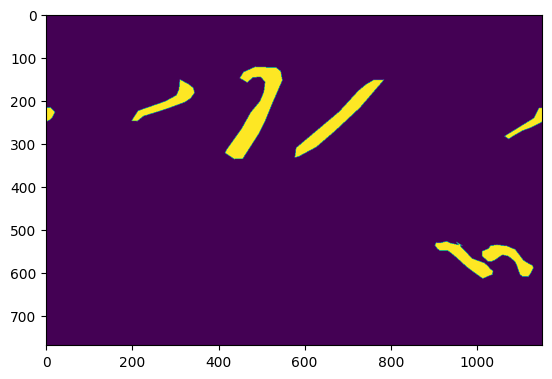

In [10]:
plt.imshow(np.array(ds[12][1])[3,0,:,:]>0)

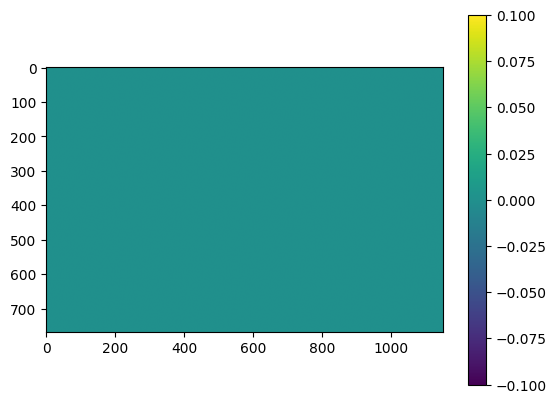

In [12]:
plt.imshow(np.array(all_estimated_L_masks_posterior_mean)[0,:,:])
plt.colorbar()

In [ ]:
## DAWID-SKENE Model

In [7]:
import pymc3 as pm
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

ModuleNotFoundError: No module named 'pymc3'

In [8]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS

def ds_model(Y):
    N, R = Y.shape
    pi    = pyro.sample("pi", dist.Beta(1., 1.))
    alpha = pyro.sample("alpha", dist.Beta(2., 2.).expand([R]).to_event(1))
    beta  = pyro.sample("beta",  dist.Beta(2., 2.).expand([R]).to_event(1))

    with pyro.plate("pixels", N):
        z = pyro.sample("z", dist.Bernoulli(pi))
        probs = z.unsqueeze(-1)*alpha + (1-z).unsqueeze(-1)*(1-beta)
        pyro.sample("y_obs", dist.Bernoulli(probs), obs=Y)

# Run
nuts = NUTS(ds_model)
mcmc = MCMC(nuts, num_samples=1000, warmup_steps=500)
mcmc.run(Y)
posterior = mcmc.get_samples()


ModuleNotFoundError: No module named 'pyro'

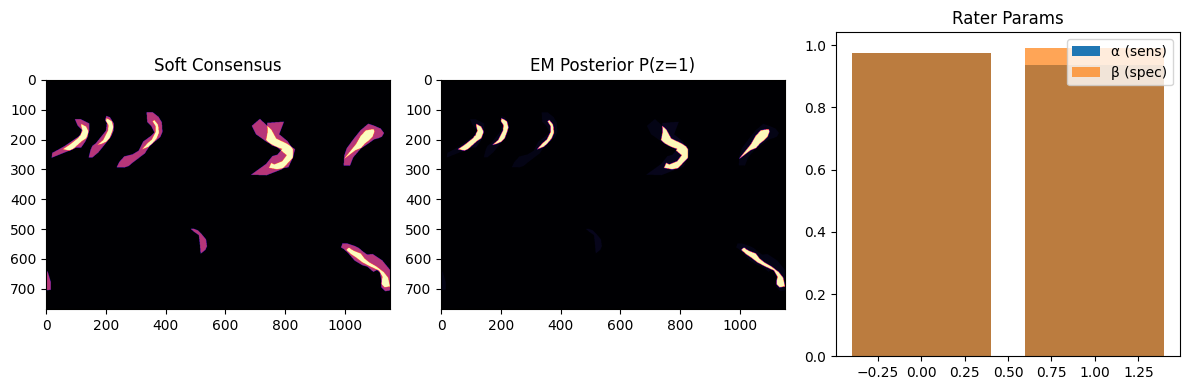

In [ ]:
import numpy as np
import torch

def dawid_skene_em(rater_masks: np.ndarray,
                   n_iter: int = 20,
                   eps: float = 1e-10):
    """
    rater_masks: np.ndarray, shape (R, H, W), values 0 or 1
    returns:
      z_prob: np.ndarray, shape (H, W) = P(z=1 | all y)
      alpha:  np.ndarray, shape (R,)   sensitivity estimates
      beta:   np.ndarray, shape (R,)   specificity estimates
    """
    R, H, W = rater_masks.shape
    P = H*W
    Y = rater_masks.reshape(R, P)      # shape (R, P)

    # initialize z by majority vote
    z_prob = Y.mean(axis=0)            # in [0,1], shape (P,)
    pi = z_prob.mean()                 # prior P(z=1)

    # initialize rater params
    alpha = np.full(R, 0.9)            # P(y=1 | z=1)
    beta  = np.full(R, 0.9)            # P(y=0 | z=0)

    for _ in range(n_iter):
        # --- E-step: posterior P(z=1 | y) ---
        # numerator   = pi * ∏_r α_r^y_r (1-α_r)^(1-y_r)
        # denominator = that + (1-pi) * ∏_r (1-β_r)^y_r β_r^(1-y_r)
        log_num   = np.log(pi+eps) \
                    + ((Y * np.log(alpha[:,None]+eps)
                        + (1-Y)*np.log(1-alpha[:,None]+eps))).sum(axis=0)
        log_denom = np.log(1-pi+eps) \
                    + ((Y * np.log(1-beta[:,None]+eps)
                        + (1-Y)*np.log(beta[:,None]+eps))).sum(axis=0)
        # use log-sum-exp for stability
        M = np.maximum(log_num, log_denom)
        num   = np.exp(log_num  - M)
        denom = np.exp(log_denom - M)
        z_prob = num / (num + denom)   # shape (P,)

        # --- M-step: update pi, alpha, beta ---
        pi = z_prob.mean()

        # α_r = sum_i P(z_i=1)*y_{r,i} / sum_i P(z_i=1)
        alpha = (z_prob * Y).sum(axis=1) / (z_prob.sum() + eps)

        # β_r = sum_i (1-P(z_i))* (1 - y_{r,i}) / sum_i (1-P(z_i))
        invz = 1-z_prob
        beta  = (invz * (1-Y)).sum(axis=1) / (invz.sum() + eps)

    # reshape z back to (H,W)
    z_map = z_prob.reshape(H, W)
    return z_map, alpha, beta

# ─────────────────────────────────────────────────────────────────────────────
# Example usage with your ARMultiAnnDataset for one image (#i):
from train_model import ARMultiAnnDataset, collate_var
from torch.utils.data import DataLoader

# 1) load one date
ds = ARMultiAnnDataset("/home/sbk29/data/AR/test", ["TMQ"])
x, y_list, y_cons = ds[12]   # x:[C,H,W], y_list: list of [1,H,W] masks


# 2) convert to numpy array shape (R,H,W)
rater_masks = torch.stack(y_list, dim=0).squeeze(1).numpy()  # [R,H,W]

# 3) run EM
z_map, alpha_est, beta_est = dawid_skene_em(rater_masks, n_iter=50)

# 4) visualize
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(12,4))
ax[0].imshow(y_cons[0].numpy(), cmap="magma", vmin=0, vmax=1)
ax[0].set_title("Soft Consensus")
ax[1].imshow(z_map, cmap="magma", vmin=0, vmax=1)
ax[1].set_title("EM Posterior P(z=1)")
ax[2].bar(np.arange(len(alpha_est)), alpha_est, label="α (sens)")
ax[2].bar(np.arange(len(beta_est)),  beta_est,  label="β (spec)", alpha=0.7)
ax[2].legend(); ax[2].set_title("Rater Params")
plt.tight_layout()
plt.show()


In [20]:
# 1) load one date
ds = ARMultiAnnDataset("/home/sbk29/data/AR/train", ["TMQ"])
x, y_list, y_cons = ds[12]   # x:[C,H,W], y_list: list of [1,H,W] masks



In [32]:
y_cons2 = y_cons> 0

In [33]:
np.unique(y_cons2)

array([False,  True])

In [17]:
def masks_to_list(rater_masks):
    """
    rater_masks: list of R tensors [H,W] of 0/1
    returns: nested list [task][worker] -> [label]
    """
    R, H, W = len(rater_masks), *rater_masks[0].shape
    dataset_list = []

    # flatten pixel index: task_id = r * H + c
    for r_pix in range(H):
        for c_pix in range(W):
            worker_labels = []
            for m in rater_masks:
                label = int(m[r_pix, c_pix])
                worker_labels.append([label])  # wrap in list so list2array counts it
            dataset_list.append(worker_labels)
    return dataset_list, H, W


In [18]:
import logging

import numpy as np

def list2array(class_num, dataset_list):
    task_num, worker_num, class_num = len(dataset_list), len(dataset_list[0]), class_num
    dataset_tensor = np.zeros((task_num, worker_num, class_num))

    for task_i in range(task_num): 
        for worker_j in range(worker_num): 
            for predict_label_k in dataset_list[task_i][worker_j]:
                dataset_tensor[task_i][worker_j][predict_label_k] += 1

    return dataset_tensor

class DawidSkeneModel:
    def __init__(self,
                 class_num,
                 max_iter = 100,
                 tolerance = 0.01) -> None:
        self.class_num = class_num
        self.max_iter = max_iter
        self.tolerance = tolerance

    def run(self, dataset):
        self.task_num, self.worker_num, _ = dataset.shape
        self.dataset_tensor = dataset
        predict_label =  self.dataset_tensor.sum(1) / self.dataset_tensor.sum(1).sum(1).reshape(-1, 1)

        flag = True
        prev_error_rates, prev_predict_label = None, None
        iter_num = 0

        while flag:
            error_rates = self._m_step(predict_label)
            next_predict_label = self._e_step(predict_label, error_rates)
            log_L = self._get_likelihood(predict_label, error_rates)

            if iter_num == 0:
                logging.info("{}\t{}".format(iter_num, log_L))
            else:
                marginal_predict = np.sum(predict_label, 0) / self.task_num
                prev_marginal_predict = np.sum(prev_predict_label, 0) / self.task_num
                marginals_diff = np.sum(np.abs(marginal_predict - prev_marginal_predict))
                error_rates_diff = np.sum(np.abs(error_rates - prev_error_rates))

                if self._check_condition(marginals_diff, error_rates_diff, iter_num):
                    flag = False

            prev_error_rates = error_rates
            prev_predict_label = predict_label
            predict_label = next_predict_label
            iter_num += 1

        worker_reliability = {}
        for i in range(self.worker_num):
            ie_rates = marginal_predict * error_rates[i, :, :]
            reliability = np.sum(np.diag(ie_rates))
            worker_reliability[i] = reliability
            
        return marginal_predict, error_rates, worker_reliability, predict_label

    def _check_condition(self, marginals_diff, error_rates_diff, iter_num):
        return (marginals_diff < self.tolerance and error_rates_diff < self.tolerance) or iter_num > self.max_iter

    def _m_step(self, predict_label):
        error_rates = np.zeros((self.worker_num, self.class_num, self.class_num))

        # Equation 2.3
        for i in range(self.class_num):
            worker_error_rate = np.dot(predict_label[:, i], self.dataset_tensor.transpose(1, 0 ,2))
            sum_worker_error_rate = worker_error_rate.sum(1)
            sum_worker_error_rate = np.where(sum_worker_error_rate == 0 , -10e9, sum_worker_error_rate)
            error_rates[:, i, :] = worker_error_rate / sum_worker_error_rate.reshape(-1,1)                                                                        
        return error_rates
    
    def _e_step(self, predict_label, error_rates):
        marginal_probability = predict_label.sum(0) / self.task_num
        next_predict_label = np.zeros([self.task_num, self.class_num])

        # Equation 2.5
        for i in range(self.task_num):
            class_likelood = self._get_class_likelood(error_rates, self.dataset_tensor[i])
            next_predict_label[i] = marginal_probability * class_likelood
            sum_marginal_probability = next_predict_label[i].sum()
            sum_marginal_probability = np.where(sum_marginal_probability == 0 , -10e9, sum_marginal_probability)
            next_predict_label[i] /= sum_marginal_probability
        return next_predict_label

    def _get_likelihood(self, predict_label, error_rates):
        log_L = 0
        marginal_probability = predict_label.sum(0) / self.task_num

        # Equation 2.7
        for i in range(self.task_num):
            class_likelood = self._get_class_likelood(error_rates, self.dataset_tensor[i])
            log_L += np.log((marginal_probability * class_likelood).sum())
        return log_L

    def _get_class_likelood(self, error_rates, task_tensor):
        # \sum_{j=1}^J p_{j} \prod_{k=1}^K \prod_{l=1}^J\left(\pi_{j l}^{(k)}\right)^{n_{il}^{(k)}}
        return np.power(error_rates.transpose(0, 2, 1), np.broadcast_to(task_tensor.reshape(self.worker_num, self.class_num, 1), (self.worker_num, self.class_num, self.class_num))).transpose(1, 2, 0).prod(0).prod(1)

In [52]:
# y_list is the list of torch tensors [1,H,W] for this image
rater_masks_np = [m.squeeze(0).cpu().numpy().astype(int) for m in y_list]
dataset_list, H, W = masks_to_list(rater_masks_np)
tensor_3d = list2array(class_num=2, dataset_list=dataset_list)

ds = DawidSkeneModel(class_num=2, max_iter=100, tolerance=1e-6)
marginal, err_rates, reliability, post_per_task = ds.run(tensor_3d)
# marginal shape = (2,)  (overall class priors)
# post_per_task   = (task_num, 2)   soft P(z=0/1) per pixel
posterior_map = post_per_task[:,1].reshape(H, W)   # probability AR


In [53]:
reliability

{0: 0.9548725269466356,
 1: 0.9714134816195249,
 2: 0.969728012198154,
 3: 0.9549563606624107}

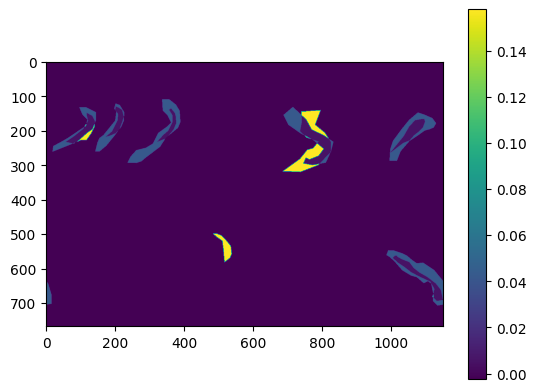

In [37]:
plt.imshow(- posterior_map+np.array(y_cons[0,:,:]))
plt.colorbar()

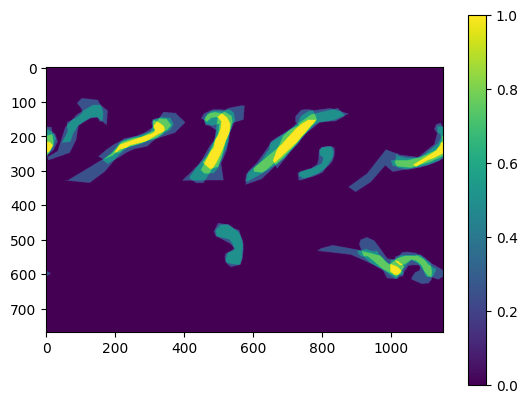

In [18]:
plt.imshow(y_cons[0,:,:])
plt.colorbar()

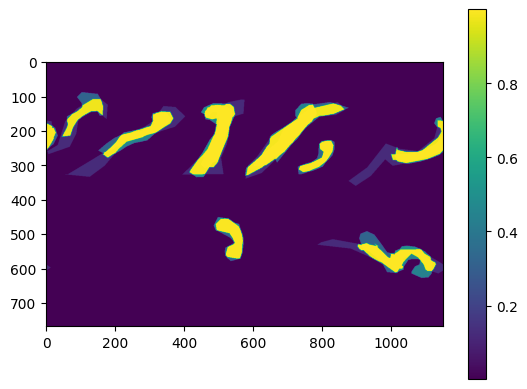

In [55]:
plt.imshow(posterior_map)
plt.colorbar()

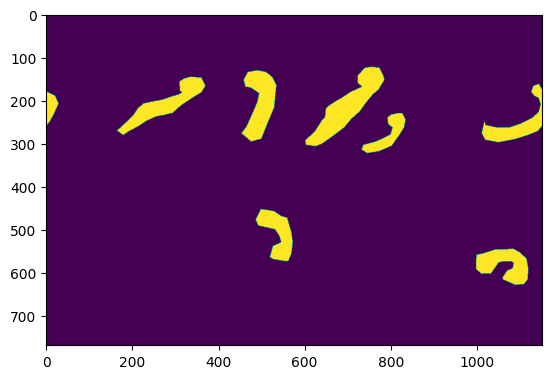

In [51]:
plt.imshow(y_list[1][0,:,:])

In [31]:
p1 = np.load("/home/sbk29/data/github_AR/AR_detection/u-net/ds_results/posterior_map_182.npy")

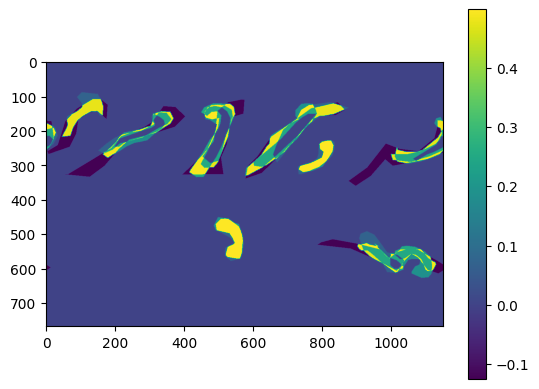

In [16]:
plt.imshow(p1 - np.array(y_cons[0,:,:]))
plt.colorbar()

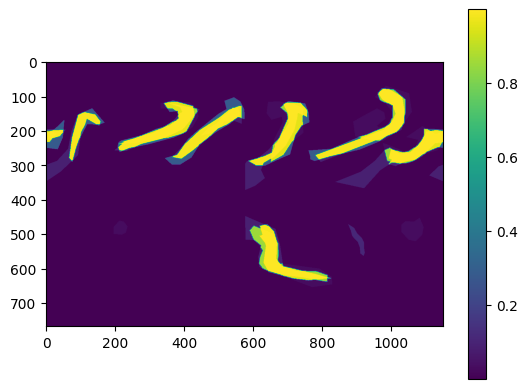

In [32]:
plt.imshow(p1)
plt.colorbar()

In [22]:
ds.samples


[('1996-06-09',
  {0: PosixPath('/home/sbk29/data/AR/train/data-1996-06-09-01-1_0.nc')}),
 ('1996-07-11',
  {0: PosixPath('/home/sbk29/data/AR/train/data-1996-07-11-01-1_0.nc')}),
 ('1996-07-18',
  {1: PosixPath('/home/sbk29/data/AR/train/data-1996-07-18-01-1_1.nc'),
   2: PosixPath('/home/sbk29/data/AR/train/data-1996-07-18-01-1_2.nc'),
   0: PosixPath('/home/sbk29/data/AR/train/data-1996-07-18-01-1_0.nc')}),
 ('1996-09-01',
  {0: PosixPath('/home/sbk29/data/AR/train/data-1996-09-01-01-1_0.nc'),
   1: PosixPath('/home/sbk29/data/AR/train/data-1996-09-01-01-1_1.nc')}),
 ('1996-09-12',
  {0: PosixPath('/home/sbk29/data/AR/train/data-1996-09-12-01-1_0.nc')}),
 ('1996-09-26',
  {1: PosixPath('/home/sbk29/data/AR/train/data-1996-09-26-01-1_1.nc'),
   0: PosixPath('/home/sbk29/data/AR/train/data-1996-09-26-01-1_0.nc')}),
 ('1996-10-03',
  {0: PosixPath('/home/sbk29/data/AR/train/data-1996-10-03-01-1_0.nc'),
   1: PosixPath('/home/sbk29/data/AR/train/data-1996-10-03-01-1_1.nc')}),
 ('1997-06

In [5]:

import re
from pathlib import Path
import numpy as np
import torch
import xarray as xr
from typing import List, Tuple, Optional

FNAME_RE = re.compile(r"data-(\d{4}-\d{2}-\d{2})-.*?_(\d+)\.nc$")
POST_RE  = re.compile(r"posterior_map_(\d+)\.npy$")

class ARMultiAnnDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        root:        str | Path,
        var_names:   List[str],
        gt_npy_root: Optional[str | Path] = None,
    ):
        super().__init__()
        self.root, self.var_names = Path(root), var_names

        # ——— 1) build the list of dates → annotator files ———
        by_date = {}
        for f in self.root.glob("*.nc"):
            m = FNAME_RE.search(f.name)
            if not m:
                continue
            date, ann_id = m.group(1), int(m.group(2))
            by_date.setdefault(date, {})[ann_id] = f

        if not by_date:
            raise RuntimeError(f"No .nc files found in {self.root!r}")
        # sorted list of (date, {ann_id: Path})
        self.samples = sorted(by_date.items())
        self.real_max_ann = max(len(d) for _, d in self.samples)

        # ——— 2) collect your posterior_map_{k}.npy files ———
        if gt_npy_root is not None:
            npy_root = Path(gt_npy_root)
            candidates = []
            for p in npy_root.glob("posterior_map_*.npy"):
                mm = POST_RE.search(p.name)
                if mm:
                    idx = int(mm.group(1))
                    candidates.append((idx, p))
            # sort by that integer index
            candidates.sort(key=lambda x: x[0])
            if len(candidates) != len(self.samples):
                raise ValueError(
                    f"Found {len(candidates)} posterior_map_*.npy but {len(self.samples)} dates"
                )
            # unzip into parallel lists
            self.npy_indices, self.npy_files = zip(*candidates)
        else:
            self.npy_indices = None
            self.npy_files   = [None] * len(self.samples)

    def _load_nc(self, path: Path) -> Tuple[torch.Tensor, torch.Tensor]:
        ds = xr.open_dataset(path, engine="netcdf4")
        x = torch.stack([
            torch.as_tensor(ds[v].values).squeeze()
            for v in self.var_names
        ]).float()               # [C, H, W]
        raw = torch.as_tensor(ds["LABELS"].values).squeeze()
        y   = (raw == 2).float().unsqueeze(0)  # [1, H, W]
        ds.close()
        return x, y

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        date, ann_map = self.samples[idx]

        # A) load annotator masks
        x_vars, y_list = None, []
        for p in ann_map.values():
            x, y = self._load_nc(p)
            if x_vars is None:
                x_vars = x
            y_list.append(y)

        # B) compute soft consensus
        y_cons = torch.stack(y_list).mean(0)  # [1, H, W]

        # C) override with ground-truth npy if available
        npy_path = self.npy_files[idx]
        if npy_path is not None:
            arr = np.load(npy_path)        # shape [H,W] or [1,H,W]
            if arr.ndim == 2:
                arr = arr[None]
            y_cons = torch.from_numpy(arr).float()

        return x_vars, y_list, y_cons

def collate_var(batch):
    xs, y_lists, y_cons = zip(*batch)
    return torch.stack(xs), list(y_lists), torch.stack(y_cons)


In [6]:
ds = ARMultiAnnDataset(
    root="/home/sbk29/data/AR/train",
    var_names=["TMQ"],
    gt_npy_root="/home/sbk29/data/github_AR/AR_detection/u-net/ds_results"
)


In [37]:
x, y_list, y_cons = ds[12] 

In [44]:
ds.samples

[('1996-06-09',
  {0: PosixPath('/home/sbk29/data/AR/train/data-1996-06-09-01-1_0.nc')}),
 ('1996-07-11',
  {0: PosixPath('/home/sbk29/data/AR/train/data-1996-07-11-01-1_0.nc')}),
 ('1996-07-18',
  {1: PosixPath('/home/sbk29/data/AR/train/data-1996-07-18-01-1_1.nc'),
   2: PosixPath('/home/sbk29/data/AR/train/data-1996-07-18-01-1_2.nc'),
   0: PosixPath('/home/sbk29/data/AR/train/data-1996-07-18-01-1_0.nc')}),
 ('1996-09-01',
  {0: PosixPath('/home/sbk29/data/AR/train/data-1996-09-01-01-1_0.nc'),
   1: PosixPath('/home/sbk29/data/AR/train/data-1996-09-01-01-1_1.nc')}),
 ('1996-09-12',
  {0: PosixPath('/home/sbk29/data/AR/train/data-1996-09-12-01-1_0.nc')}),
 ('1996-09-26',
  {1: PosixPath('/home/sbk29/data/AR/train/data-1996-09-26-01-1_1.nc'),
   0: PosixPath('/home/sbk29/data/AR/train/data-1996-09-26-01-1_0.nc')}),
 ('1996-10-03',
  {0: PosixPath('/home/sbk29/data/AR/train/data-1996-10-03-01-1_0.nc'),
   1: PosixPath('/home/sbk29/data/AR/train/data-1996-10-03-01-1_1.nc')}),
 ('1997-06

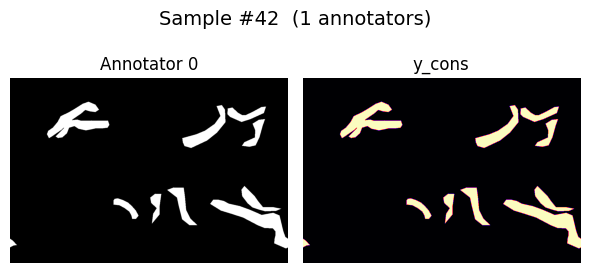

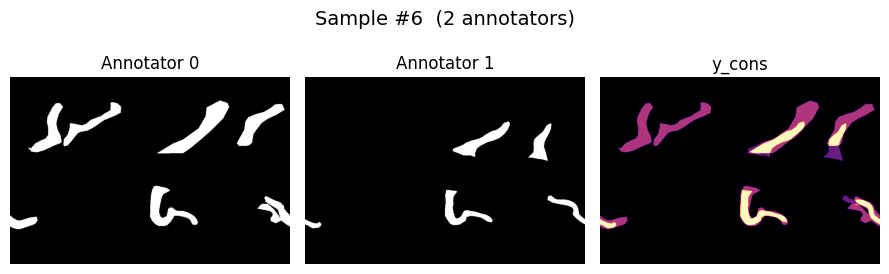

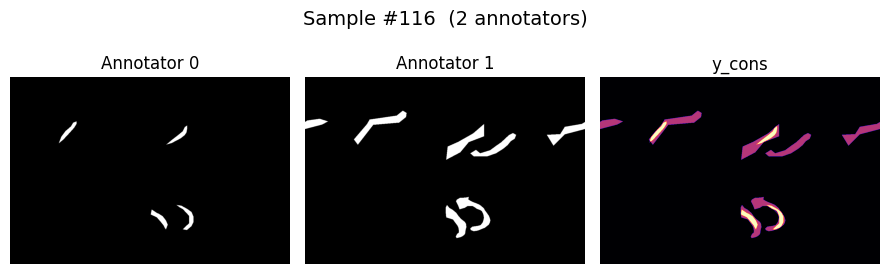

In [10]:
import random
import matplotlib.pyplot as plt
import torch

# ───── Instantiate your dataset ─────
ds = ARMultiAnnDataset(
    root="/home/sbk29/data/AR/train",
    var_names=["TMQ"],
    gt_npy_root="/home/sbk29/data/github_AR/AR_detection/u-net/ds_results"  # or None if you don’t have npy overrides
)

# ───── Pick 3 random samples ─────
n_plots = 3
indices = random.sample(range(len(ds)), n_plots)

for i, idx in enumerate(indices):
    x_vars, y_list, y_cons = ds[idx]   # y_list: List of [1,H,W]; y_cons: [1,H,W]
    R = len(y_list)
    
    fig, axes = plt.subplots(1, R+1, figsize=(3*(R+1), 3))
    fig.suptitle(f"Sample #{idx}  ({R} annotators)", fontsize=14)
    
    # plot each annotator mask
    for r, y in enumerate(y_list):
        axes[r].imshow(y.squeeze(0).cpu(), cmap="gray", vmin=0, vmax=1)
        axes[r].set_title(f"Annotator {r}")
        axes[r].axis("off")
    
    # plot consensus / ground‐truth
    axes[-1].imshow(y_cons.squeeze(0).cpu(), cmap="magma", vmin=0, vmax=1)
    axes[-1].set_title("y_cons")
    
    axes[-1].axis("off")
    
    plt.tight_layout()
    plt.show()
